In [1]:
"""
================================================================================
Step 4: Analyze the same video with YOLO Pose and compare with MediaPipe
================================================================================

Prerequisites: Steps 1-3 must be completed

Goals:
  1. Understand how YOLO Pose works
  2. Analyze the same video from Step 3 using YOLO
  3. Compare MediaPipe vs YOLO results with numbers and graphs
  4. Submit the comparison report to the professor

Only cells 5 and 6 differ from Step 3!
  Angle calculation and graph creation reuse exactly the same code.
================================================================================
"""

# # Step 4: Comparing YOLO Pose and MediaPipe
#
# ## Why compare two models?
#
# | Comparison item | MediaPipe | YOLO Pose |
# |----------------|-----------|-----------|
# | Keypoint count | **33 points** (incl. fingers) | **17 points** (major joints only) |
# | 3D coordinates | Yes (depth) | No (2D only) |
# | Multi-person detection | Up to 5 | **No limit** |
# | GPU needed | No (CPU OK) | Yes (GPU recommended) |
# | Best use case | Single-person form analysis | **Contact plays like tackles** |
#
# By analyzing the same video with both models, you can argue numerically
# "which is more suitable for rugby analysis" — a strong report for the professor.
#
# ## Relationship with Step 3
# ```
# What was built in Step 3:              What is built in Step 4 (this time):
# ├── Angle calculation with MediaPipe   ├── Angle calculation with YOLO Pose  <- only detection changes
# ├── Time-series graphs                 ├── YOLO time-series graphs
# ├── CSV output                         ├── YOLO CSV output
# └── Annotated video                    ├── YOLO annotated video
#                                        └── [NEW] Comparison graphs & report for two models
# ```


'\n================================================================================\nStep 4: Analyze the same video with YOLO Pose and compare with MediaPipe\n================================================================================\n\nPrerequisites: Steps 1-3 must be completed\n\nGoals:\n  1. Understand how YOLO Pose works\n  2. Analyze the same video from Step 3 using YOLO\n  3. Compare MediaPipe vs YOLO results with numbers and graphs\n  4. Submit the comparison report to the professor\n\nOnly cells 5 and 6 differ from Step 3!\n  Angle calculation and graph creation reuse exactly the same code.\n================================================================================\n'

In [2]:
# ============================================================
# Cell 1: Import libraries
# ============================================================

# install missing package for OpenCV
%pip install opencv-python

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import cv2
import os
import csv
import time
import json

print("Libraries loaded successfully")


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Libraries loaded successfully


In [3]:
# ============================================================
# Analysis helper functions
# ============================================================

def calculate_angle(a, b, c):
    ba = a - b
    bc = c - b
    cos_theta = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    return float(np.degrees(np.arccos(cos_theta)))

def calculate_angular_velocity(angles, fps):
    dt = 1.0 / fps
    n = len(angles)
    if n < 2:
        return [0.0] * n
    velocities = []
    for i in range(n):
        if i == 0:
            omega = (angles[1] - angles[0]) / dt
        elif i == n - 1:
            omega = (angles[-1] - angles[-2]) / dt
        else:
            omega = (angles[i + 1] - angles[i - 1]) / (2 * dt)
        velocities.append(omega)
    return velocities

def calculate_joint_speed(positions, fps):
    dt = 1.0 / fps
    speeds = [0.0]
    for i in range(1, len(positions)):
        distance = np.linalg.norm(
            np.array(positions[i]) - np.array(positions[i - 1]))
        speeds.append(distance / dt)
    return speeds

def calculate_trunk_inclination(left_shoulder, right_shoulder, left_hip, right_hip):
    mid_shoulder = (np.array(left_shoulder) + np.array(right_shoulder)) / 2
    mid_hip = (np.array(left_hip) + np.array(right_hip)) / 2
    trunk_vector = mid_shoulder - mid_hip
    return (float(np.degrees(np.arctan2(trunk_vector[0], trunk_vector[1]))))

# Joint angle definitions (same as Step 3)
JOINT_ANGLE_DEFS = {
    "right_elbow":  ("right_shoulder", "right_elbow", "right_wrist"),
    "left_elbow":   ("left_shoulder",  "left_elbow",  "left_wrist"),
    "right_knee":   ("right_hip",      "right_knee",  "right_ankle"),
    "left_knee":    ("left_hip",       "left_knee",   "left_ankle"),
    "right_shoulder": ("right_elbow",  "right_shoulder", "right_hip"),
    "left_shoulder":  ("left_elbow",   "left_shoulder",  "left_hip"),
    "right_hip":    ("right_shoulder", "right_hip",    "right_knee"),
    "left_hip":     ("left_shoulder",  "left_hip",     "left_knee"),
}

SPEED_JOINTS = ["right_wrist", "left_wrist", "right_ankle", "left_ankle", "nose"]

SKELETON_CONNECTIONS = [
    ("nose", "left_shoulder"), ("nose", "right_shoulder"),
    ("left_shoulder", "right_shoulder"),
    ("left_shoulder", "left_elbow"), ("left_elbow", "left_wrist"),
    ("right_shoulder", "right_elbow"), ("right_elbow", "right_wrist"),
    ("left_shoulder", "left_hip"), ("right_shoulder", "right_hip"),
    ("left_hip", "right_hip"),
    ("left_hip", "left_knee"), ("left_knee", "left_ankle"),
    ("right_hip", "right_knee"), ("right_knee", "right_ankle"),
]

print("Analysis functions and definitions loaded (same as Step 3)")


Analysis functions and definitions loaded (same as Step 3)


In [4]:
# ============================================================
# Cell 3: Understanding how YOLO Pose works
# ============================================================
#
# What is YOLO (You Only Look Once)?
#
#   As the name suggests, it detects objects by looking at the image only once.
#   This makes it an extremely fast object detection model.
#
#   Conventional detection: checks many regions of the image repeatedly -> slow
#   YOLO: processes the whole image in one pass -> fast
#
# What makes YOLO Pose special:
#
#   Standard YOLO: "There is a person here" (bounding box)
#   YOLO Pose:     "There is a person here AND the joints are here" (box + keypoints)
#
#   In other words, person detection and pose estimation happen simultaneously.
#
# Difference in processing flow compared with MediaPipe:
#
#   MediaPipe:
#     image -> [person detector] -> person region -> [pose estimator] -> keypoints
#     (2 steps: detect then estimate, separate models)
#
#   YOLO Pose:
#     image -> [YOLO model] -> bounding box + keypoints
#     (1 step: output together, single model)
#
# YOLO keypoints (17 points, COCO format):
#
#   Mapping to MediaPipe (33 points):
#   +------------------------------------------+
#   | YOLO (17 pts)        MediaPipe (33 pts)   |
#   | 0: nose              0: nose              |
#   | 1: left_eye          2: left_eye          |
#   | 2: right_eye         5: right_eye         |
#   | 3: left_ear          7: left_ear          |
#   | 4: right_ear         8: right_ear         |
#   | 5: left_shoulder     11: left_shoulder    |
#   | 6: right_shoulder    12: right_shoulder   |
#   | 7: left_elbow        13: left_elbow       |
#   | 8: right_elbow       14: right_elbow      |
#   | 9: left_wrist        15: left_wrist       |
#   | 10: right_wrist      16: right_wrist      |
#   | 11: left_hip         23: left_hip         |
#   | 12: right_hip        24: right_hip        |
#   | 13: left_knee        25: left_knee        |
#   | 14: right_knee       26: right_knee       |
#   | 15: left_ankle       27: left_ankle       |
#   | 16: right_ankle      28: right_ankle      |
#   |                                           |
#   | Joints in MediaPipe but not in YOLO:      |
#   |   finger joints (6), foot detail (4),     |
#   |   facial detail (6)                       |
#   +------------------------------------------+
#
#   -> The joints used for angle calculation (shoulder, elbow, wrist,
#      hip, knee, ankle) are common to both, so comparison is possible!

# YOLO keypoint name mapping
YOLO_KEYPOINT_NAMES = {
    0: "nose",
    1: "left_eye",    2: "right_eye",
    3: "left_ear",    4: "right_ear",
    5: "left_shoulder", 6: "right_shoulder",
    7: "left_elbow",   8: "right_elbow",
    9: "left_wrist",  10: "right_wrist",
    11: "left_hip",   12: "right_hip",
    13: "left_knee",  14: "right_knee",
    15: "left_ankle", 16: "right_ankle",
}

print("YOLO Pose basics:")
print(f"  Keypoint count: {len(YOLO_KEYPOINT_NAMES)} points")
print(f"  MediaPipe:      33 points")
print(f"  Shared major joints: shoulders, elbows, wrists, hips, knees, ankles -> angle comparison possible")


YOLO Pose basics:
  Keypoint count: 17 points
  MediaPipe:      33 points
  Shared major joints: shoulders, elbows, wrists, hips, knees, ankles -> angle comparison possible


In [5]:
# ============================================================
# Cell 4: Install YOLO Pose and prepare the video
# ============================================================

# YOLO is used via the ultralytics package
%pip install ultralytics --upgrade

from ultralytics import YOLO
print("ultralytics package is available")

# Model selection
# +---------------+--------+-------+------------------+
# | Model name    | Acc.   | Speed | Size             |
# +---------------+--------+-------+------------------+
# | yolov8n-pose  | low    | fast  | 6 MB (fastest)   |
# | yolov8s-pose  | good   | good  | 23 MB            |
# | yolov8m-pose  | good+  | good- | 52 MB            |
# | yolov8x-pose  | best   | slow  | 137 MB (highest) |
# +---------------+--------+-------+------------------+
#
# CPU: yolov8s-pose (balanced) recommended
# GPU: yolov8x-pose (highest accuracy) recommended

YOLO_MODEL = YOLO('yolo26x-pose.pt')  # Change to "yolov8x-pose.pt" if GPU is available

print(f"YOLO model in use: {YOLO_MODEL}")

# Use the same video as Step 3
#VIDEO_PATH = r"C:\Users\User\OneDrive - National University of Singapore\Videos\Clipchamp\Video Project 6\Exports\Video_kicking.mp4"
VIDEO_PATH = r"C:\Users\User\OneDrive - National University of Singapore\Videos\Clipchamp\Video Project 5\Assets\Video tackling.mp4"  # tackling

# VIDEO_PATH = "your_rugby_video.mp4"  # <- Change to your own video

if not os.path.exists(VIDEO_PATH):
    print(f"Video not found: {VIDEO_PATH}")
    print(f"Please run Step 3 first to create the test video")


print(f"Video ready: {VIDEO_PATH}")

# Video info
cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
WIDTH = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
HEIGHT = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print(f"\nVideo: {VIDEO_PATH}")
print(f"  {WIDTH}x{HEIGHT} @ {fps:.0f}fps, {TOTAL_FRAMES} frames")


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 1.2/1.2 MB 9.8 MB/s  0:00:00
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.4.21
    Uninstalling ultralytics-8.4.21:
      Successfully uninstalled ultralytics-8.4.21
Note: you may need to restart the kernel to use updated packages.
ultralytics package is available
YOLO model in use: YOLO(
  (model): PoseModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(96, 192, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(192, eps=0.001, momentum=0.03, affine=True, track

In [6]:
# ============================================================
# Cell 5: Load and understand the YOLO Pose model
# ============================================================
#
# Code differences compared with MediaPipe:
#
#   MediaPipe:
#     options = PoseLandmarkerOptions(...)
#     landmarker = PoseLandmarker.create_from_options(options)
#     result = landmarker.detect_for_video(mp_image, timestamp)
#     -> result.pose_landmarks[0]  <- list of NormalizedLandmark
#
#   YOLO:
#     model = YOLO("yolov8s-pose.pt")
#     results = model(frame)
#     -> results[0].keypoints.data  <- tensor of shape [N, 17, 3]
#       N = number of detected persons
#       17 = number of keypoints
#       3 = (x_pixel, y_pixel, confidence)
#
#   Key difference:
#     MediaPipe: returns normalized coordinates (0 to 1)
#     YOLO:      returns pixel coordinates (0 to width/height)
#     -> Convert YOLO results to normalized coordinates for comparison

print("Loading YOLO model...")
print(f"   Model: {YOLO_MODEL}")

model = YOLO(YOLO_MODEL)



import torch
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"   Device: {device}")

# Test: run detection on the first frame of the video
cap = cv2.VideoCapture(VIDEO_PATH)
ret, test_frame = cap.read()
cap.release()

if ret:
    test_results = model(test_frame, verbose=False)
    test_results = test_results[0]  # result for the first frame
    
    if test_results.keypoints is not None and test_results.keypoints.data is not None:
        n_persons = len(test_results.keypoints.data)
        print(f"Test detection successful: {n_persons} person(s) detected")
        
        # Show structure of detection result
        kpts = test_results.keypoints.data[0]
        print(f"\nRaw keypoint data (person 0):")
        print(f"\n   YOLO returns pixel coordinates -> normalize by dividing by width({WIDTH}) and height({HEIGHT})")
        print(f"   Data shape: {kpts.shape}  <- (17 keypoints, [x, y, confidence])")
        print(f"   {'#':>3s}  {'name':15s}  {'x_pixel':>8s}  {'y_pixel':>8s}  {'conf':>6s}  {'x_norm':>7s}  {'y_norm':>7s}")
        print(f"   {'-'*65}")
        
        for i in range(len(kpts)):
            name = YOLO_KEYPOINT_NAMES.get(i, f"kp_{i}")
            px,py, conf = float(kpts[i][0]), float(kpts[i][1]), float(kpts[i][2])
            nx, ny = px / WIDTH, py / HEIGHT  # normalized coordinates
            print(f"   {i:3d}  {name:15s}  {px:8.1f}  {py:8.1f}  {conf:6.2f}  {nx:7.3f}  {ny:7.3f}")
            
            
            
    else:
        print("Test detection failed: no keypoints detected")


Loading YOLO model...
   Model: YOLO(
  (model): PoseModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(96, 192, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(192, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(192, 192, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(192, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(384, 384, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(384, eps=0.001, momentu

In [7]:
# ============================================================
# Cell 6: *** Analyze video with YOLO (same structure as Step 3 loop) ***
# ============================================================
#
# This code is "almost identical" to Cell 6 in Step 3.
# Only the "detection part" changes; angle calculation is unchanged.
#
# Diff from Step 3:
#   OLD: landmarker.detect_for_video(mp_image, timestamp)
#   NEW: model(frame, verbose=False)
#   OLD: result.pose_landmarks[0]
#   NEW: results[0].keypoints.data[0]
#   OLD: normalized coordinates can be used directly
#   NEW: pixel coordinates must be divided by width/height to normalize

# Accumulator variables (exactly the same structure as Step 3)

yolo_angles = {name: [] for name in JOINT_ANGLE_DEFS}
yolo_trunk_incl = []
yolo_positions = {name: [] for name in SPEED_JOINTS}
yolo_timestamps = []
yolo_detected = 0
yolo_person_counts = []  # YOLO can detect multiple persons

print("Starting YOLO analysis loop...")
print("=" * 60)

cap = cv2.VideoCapture(VIDEO_PATH)
start_time = time.time()
frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    timestamp = frame_idx / fps
    yolo_timestamps.append(timestamp)
    
    # YOLO detection
    results = model(frame, verbose=False, conf=0.5)
    result = results[0]
    
    # The way to extract detection results differs from MediaPipe
    has_detection = (result.keypoints is not None
                     and result.keypoints.data is not None
                     and len(result.keypoints.data) > 0)
    
    if has_detection:
        yolo_detected += 1
        n_persons = len(result.keypoints.data)
        yolo_person_counts.append(n_persons)
        
        # Get keypoints for the first person (person_id=0)
        kpts = result.keypoints.data[0]  # shape: [17, 3]
        
        # Convert keypoints to dict (pixel -> normalized coordinates)
        kp = {}
        kp_vis = {}
        for i in range(len(kpts)):
            name = YOLO_KEYPOINT_NAMES.get(i)
            if name:
                px, py, conf = float(kpts[i][0]), float(kpts[i][1]), float(kpts[i][2])
                # YOLO returns pixel coordinates -> divide by width/height to normalize
                kp[name] = np.array([px / WIDTH, py / HEIGHT])  # convert to normalized coordinates
                kp_vis[name] = conf
        
        # Joint angles
        for angle_name, (a_name, b_name, c_name) in JOINT_ANGLE_DEFS.items():
            if (a_name in kp and b_name in kp and c_name in kp
                and kp_vis.get(a_name,0) > 0.3
                and kp_vis.get(b_name,0) > 0.3
                and kp_vis.get(c_name,0) > 0.3):
                angle = calculate_angle(kp[a_name], kp[b_name], kp[c_name])
            else:
                angle = yolo_angles[angle_name][-1] if yolo_angles[angle_name] else 180.0
            
            yolo_angles[angle_name].append(angle)
        
        # Trunk inclination
        req = ["left_shoulder", "right_shoulder", "left_hip", "right_hip"]
        if (all(n in kp for n in req) and all(kp_vis.get(n,0) > 0.3 for n in req)):
            incl = calculate_trunk_inclination(
                kp["left_shoulder"], kp["right_shoulder"],
                kp["left_hip"], kp["right_hip"]
            )
        else:
            incl = yolo_trunk_incl[-1] if yolo_trunk_incl else 0.0
        yolo_trunk_incl.append(incl)
        
        # Joint positions
        for jn in SPEED_JOINTS:
            if jn in kp:
                yolo_positions[jn].append(kp[jn].tolist())
            elif yolo_positions[jn]:
                yolo_positions[jn].append(yolo_positions[jn][-1])  # fill from previous frame
            else:
                yolo_positions[jn].append([0.5, 0.5])
    else:
        yolo_person_counts.append(0)
        # No detection -> fill from previous frame
        for an in JOINT_ANGLE_DEFS:
            val = yolo_angles[an][-1] if yolo_angles[an] else 180.0
            yolo_angles[an].append(val)
        incl = yolo_trunk_incl[-1] if yolo_trunk_incl else 0.0
        yolo_trunk_incl.append(incl)
        for jn in SPEED_JOINTS:
            if yolo_positions[jn]:
                yolo_positions[jn].append(yolo_positions[jn][-1])
            else:
                yolo_positions[jn].append([0.5, 0.5])
    
    if frame_idx % 10 == 0:
        pct = (frame_idx / TOTAL_FRAMES) * 100
        print(f"\r  Processing: {pct:5.1f}% ({frame_idx+1}/{TOTAL_FRAMES})", end="")
    frame_idx += 1

cap.release()
elapsed = time.time() - start_time
det_rate = yolo_detected / frame_idx * 100

print(f"\n\nYOLO analysis complete!")
print(f"  Processing time: {elapsed:.1f}s ({frame_idx/elapsed:.1f} fps)")
print(f"  Detection rate:  {det_rate:.1f}%")
if yolo_person_counts:
    print(f"  Avg persons detected: {np.mean(yolo_person_counts):.1f}")
    print(f"  Max persons detected: {max(yolo_person_counts)}")

# Compute angular velocity and joint speed
yolo_angular_vel = {n: calculate_angular_velocity(a, fps) for n, a in yolo_angles.items()}
yolo_speeds = {n: calculate_joint_speed(p, fps) for n, p in yolo_positions.items()}

print(f"  Angular velocity and joint speed calculated!")


Starting YOLO analysis loop...
  Processing:  95.2% (121/126)

YOLO analysis complete!
  Processing time: 122.4s (1.0 fps)
  Detection rate:  100.0%
  Avg persons detected: 2.3
  Max persons detected: 4
  Angular velocity and joint speed calculated!


In [8]:
# ============================================================
# Cell 7: Load MediaPipe results from Step 3
# ============================================================
#
# Load the CSV saved in Step 3.
# If the CSV is not found, run the MediaPipe analysis here.

#MP_CSV_PATH = r"C:\Rugby Coaching\output_MediaPipe_kicking\analysis_results.csv"  # Kicking
MP_CSV_PATH = r"C:\Rugby Coaching\output_MediaPipe_tackling\analysis_results.csv"  # Tackling
mp_angles = {name: [] for name in JOINT_ANGLE_DEFS}
mp_trunk_incl = []
mp_speeds = {name: [] for name in SPEED_JOINTS}
mp_timestamps = []

if os.path.exists(MP_CSV_PATH):
    print(f"Loading MediaPipe results from CSV: {MP_CSV_PATH}")
    with open(MP_CSV_PATH, "r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            mp_timestamps.append(float(row["timestamp_s"]))
            for an in JOINT_ANGLE_DEFS:
                val = row.get(f'angle_{an}','')
                mp_angles[an].append(float(val) if val else 180.0)
            val = row.get("trunk_inclination_deg", "")
            mp_trunk_incl.append(float(val) if val else 0.0)
            for name in SPEED_JOINTS:
                val = row.get(f"speed_{name}", "")
                mp_speeds[name].append(float(val) if val else 0.0)
    print("MediaPipe results loaded from CSV")
else:
    print(f"MediaPipe CSV not found: {MP_CSV_PATH}")
    print("   Please run Step 3 first to generate mediapipe_results.csv")


Loading MediaPipe results from CSV: C:\Rugby Coaching\output_MediaPipe_tackling\analysis_results.csv
MediaPipe results loaded from CSV


✅ 比較グラフ1を保存: C:\Rugby Coaching\output_YoloPose_Tackling_26\angle_comparison.png
✅ 比較グラフ2を保存: C:\Rugby Coaching\output_YoloPose_Tackling_26\comparison_trunk_speed.png
✅ 比較グラフ3を保存: C:\Rugby Coaching\output_YoloPose_Tackling_26\comparison_bar_chart.png

📊 保存した比較グラフをノートブック上に表示します

1) Joint Angle Comparison


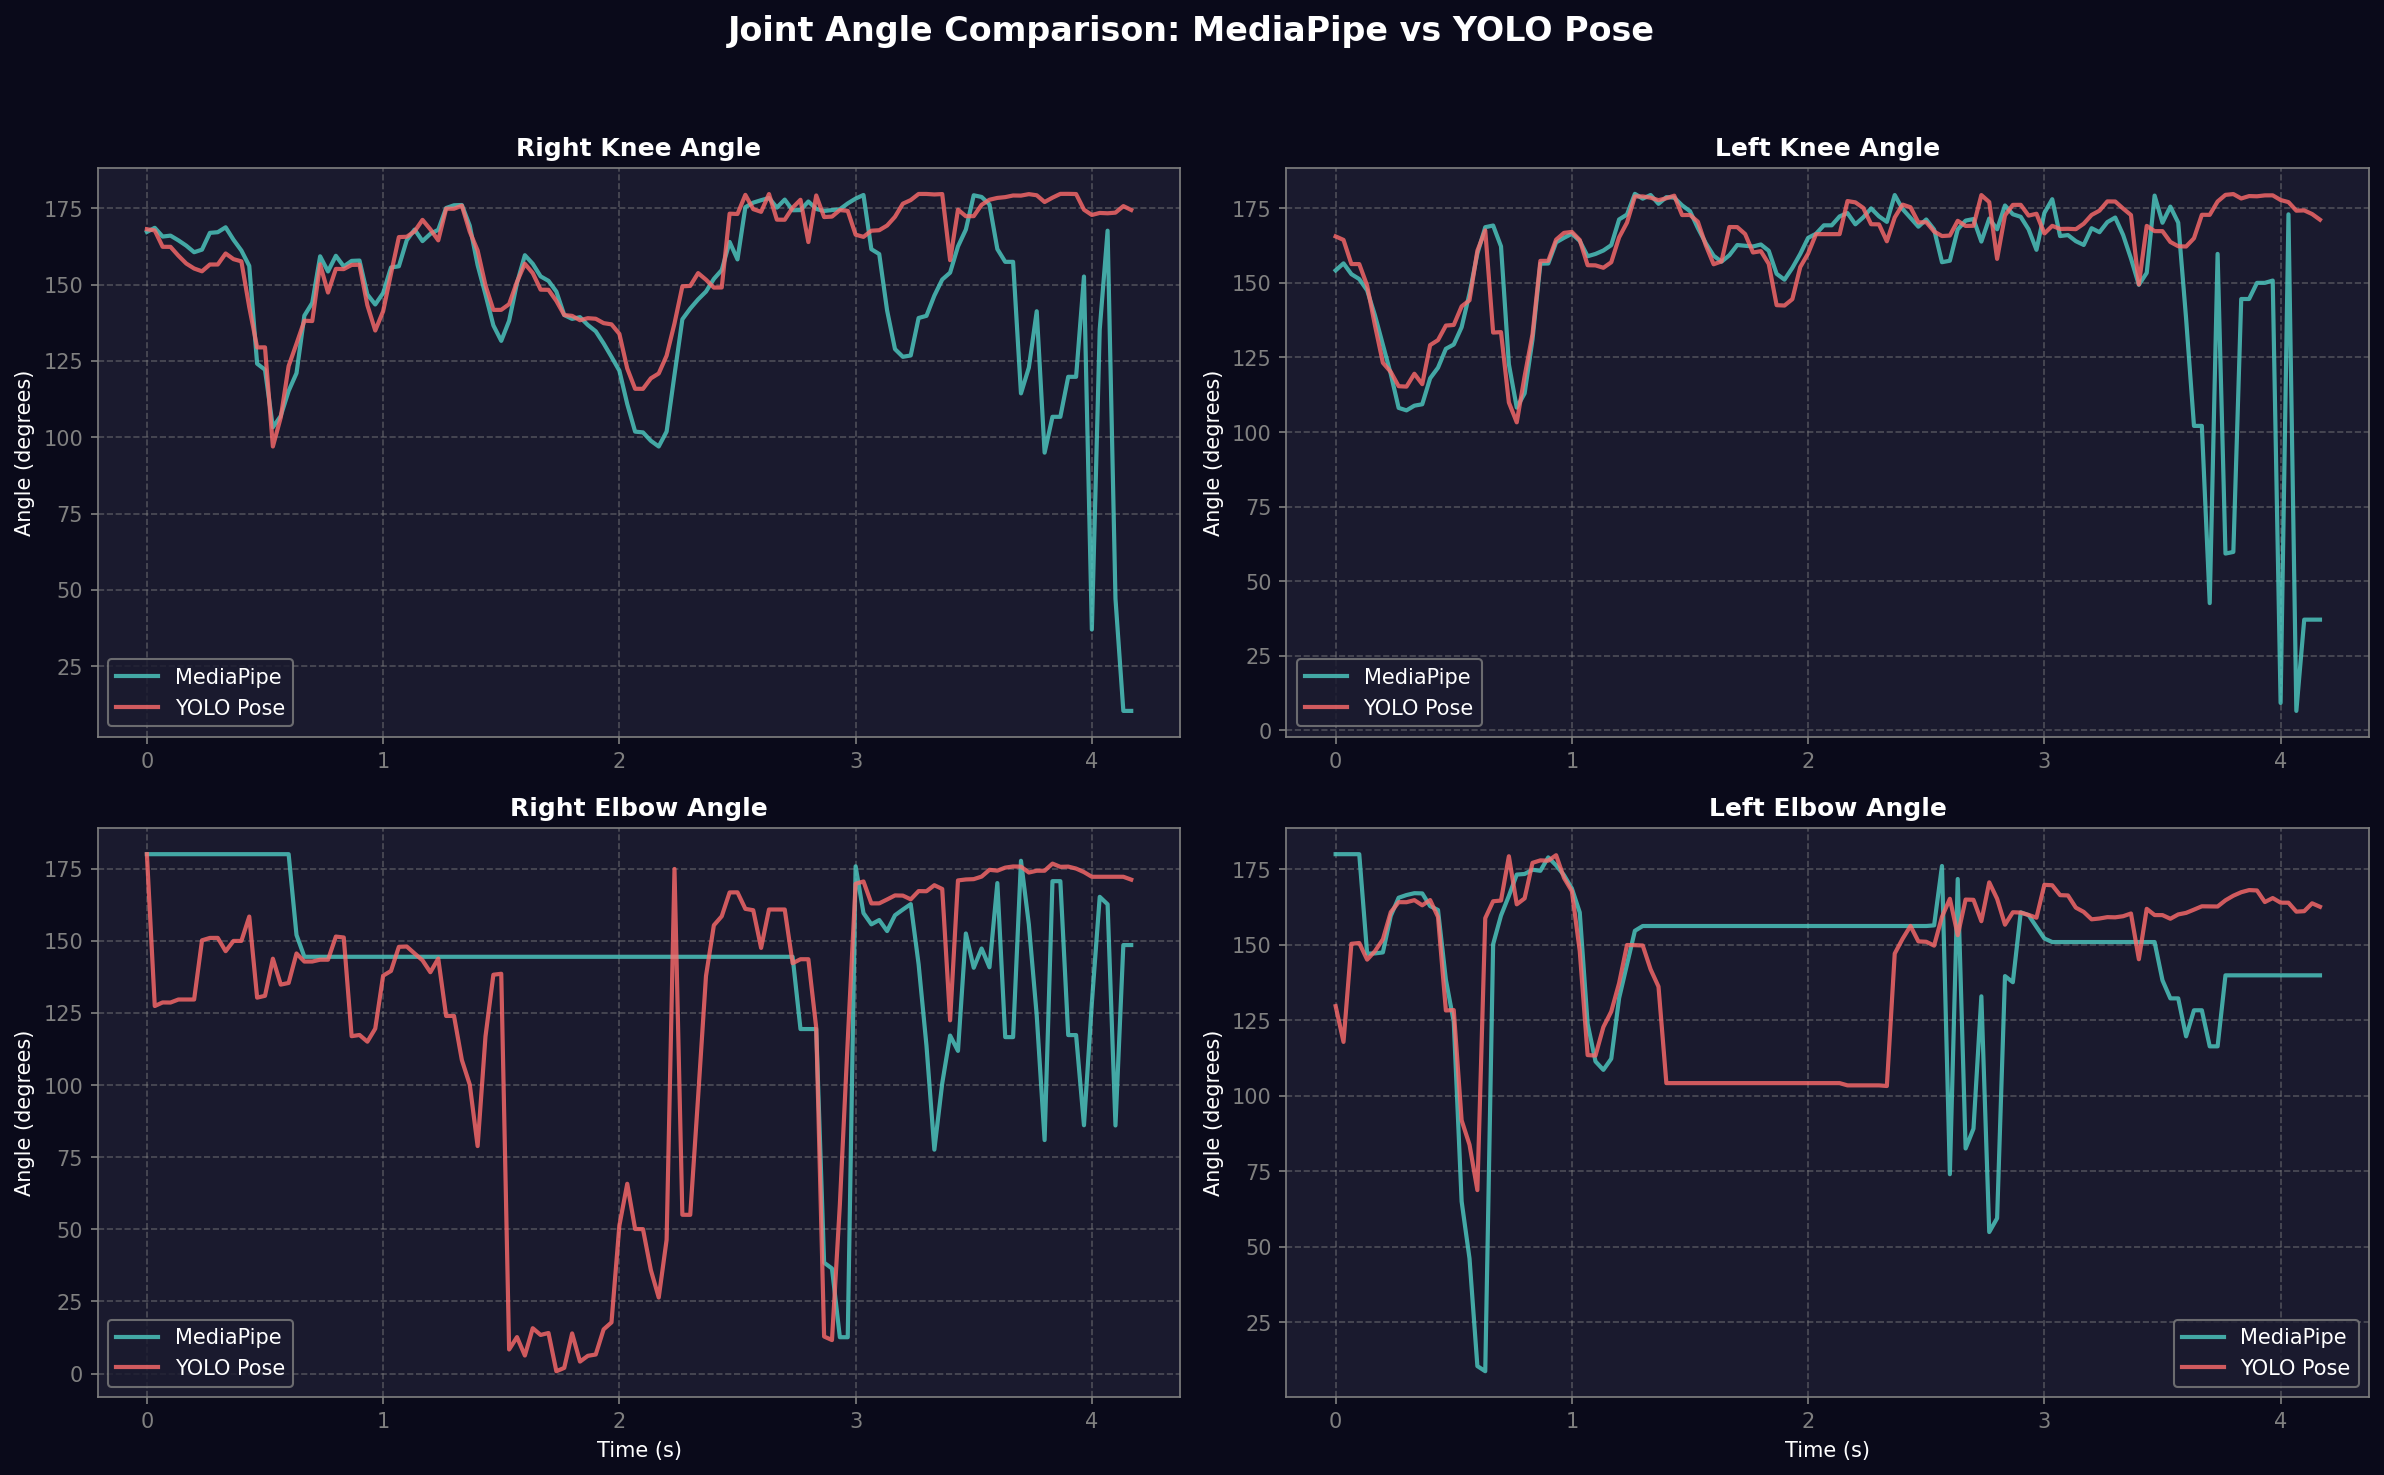


2) Trunk Inclination & Right Wrist Speed


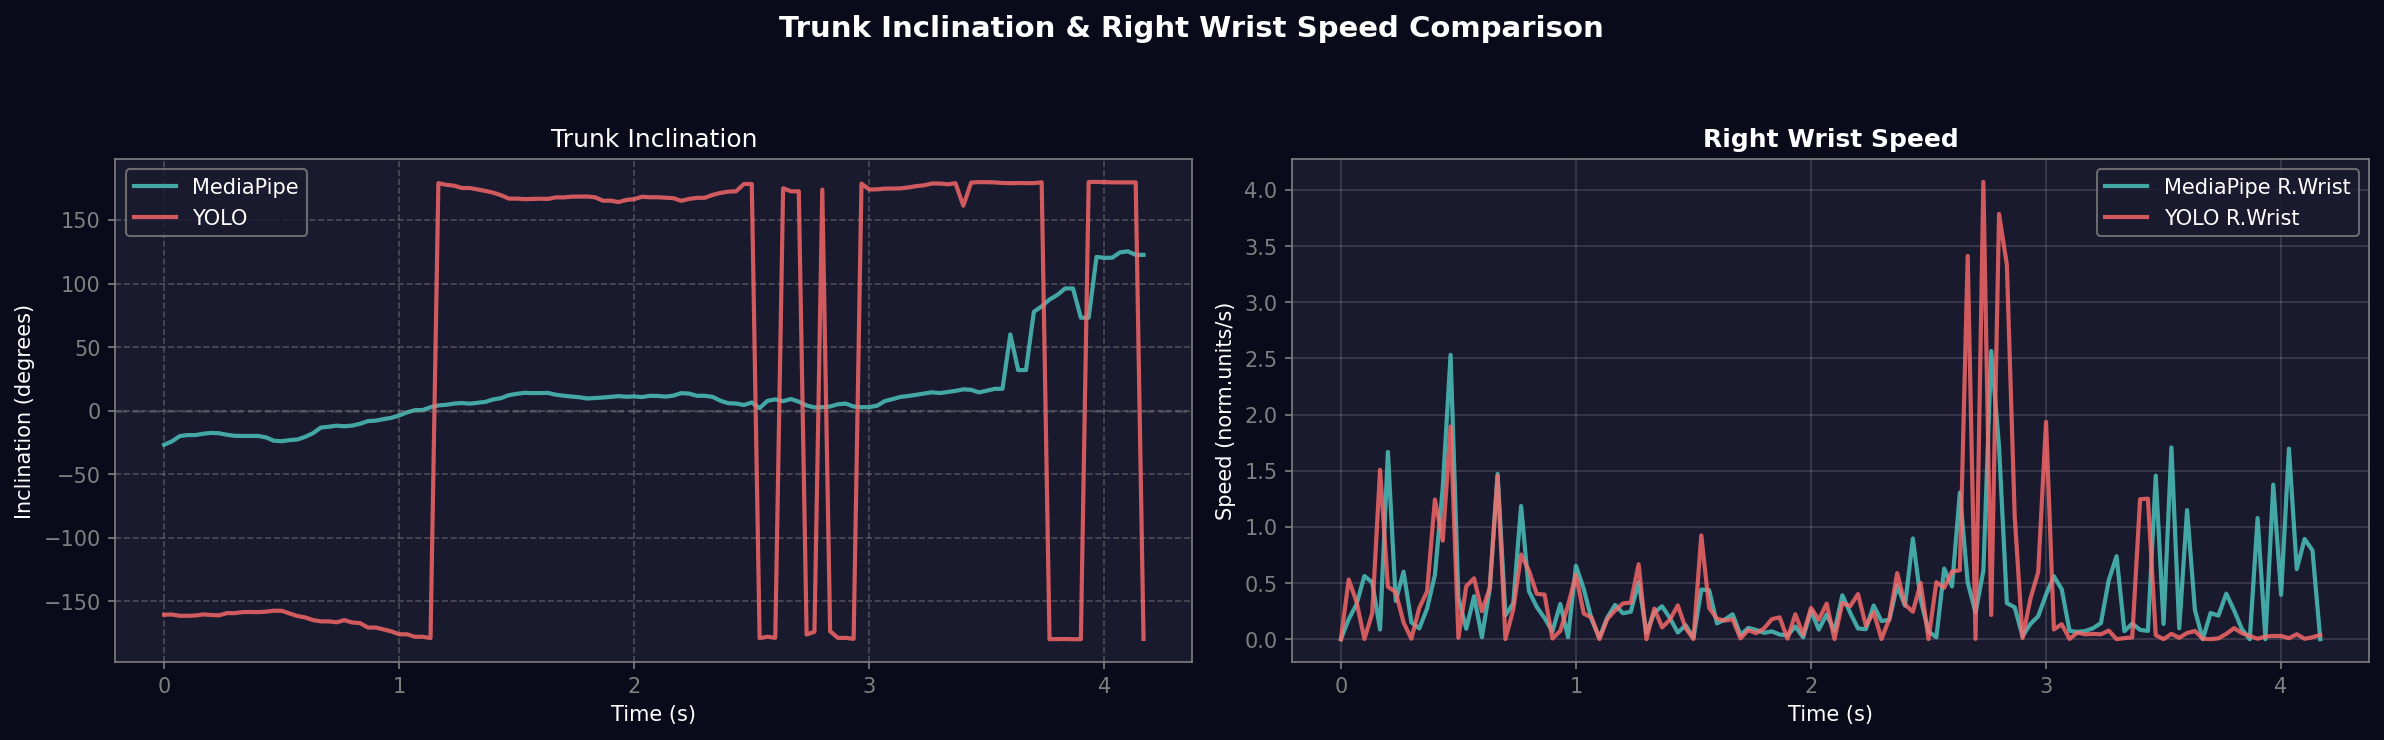


3) Quantitative Comparison


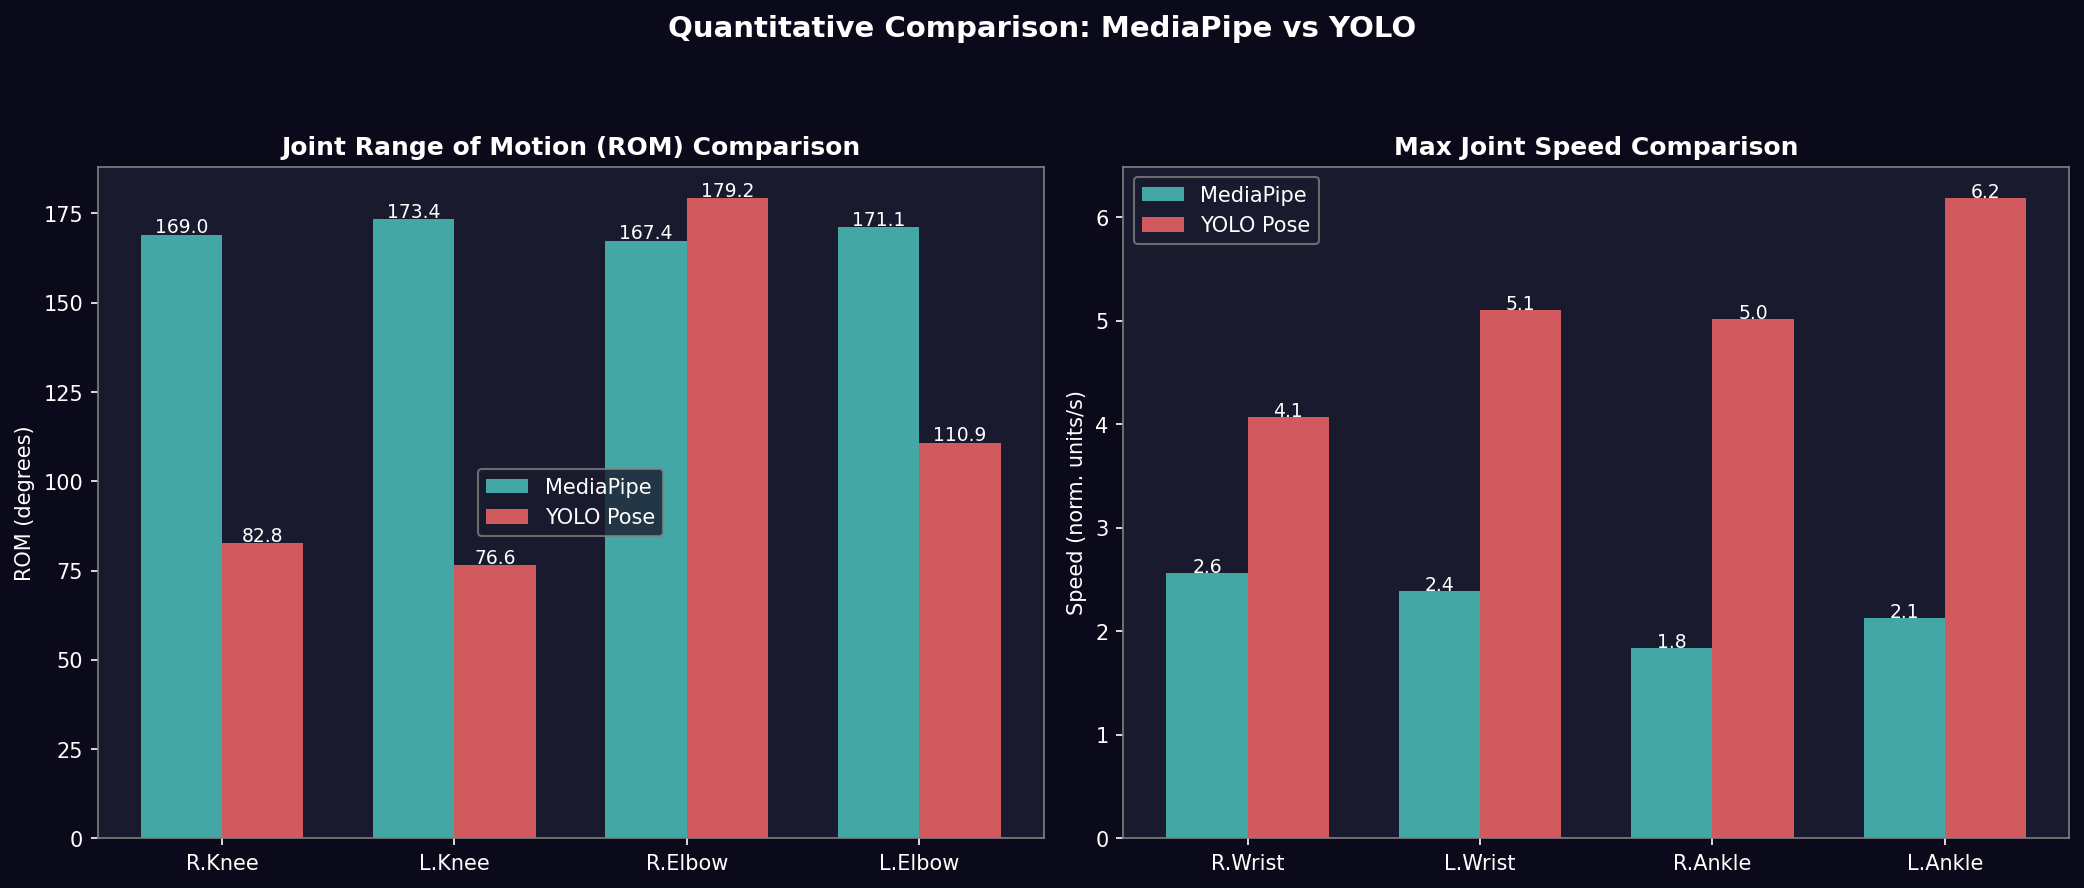

In [9]:
# ============================================================
# セル8: ★★★ 比較グラフの作成（教授提出用 ★）★★★
# ============================================================

from IPython.display import Image as IPImage, display

OUTPUT_DIR = r"C:\Rugby Coaching\output_YoloPose_Tackling_26"


os.makedirs(OUTPUT_DIR, exist_ok=True)

DARK_BG = '#0a0a1a'
PANEL_BG = '#1a1a2e'
MP_COLOR = '#4ecdc4'    # MediaPipe = 青緑
YOLO_COLOR = '#ff6b6b'  # YOLO = 赤

# ── 比較グラフ1: 関節角度の重ね描き ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor(DARK_BG)

comparisons = [
    ("right_knee",  "Right Knee Angle", 0, 0),
    ("left_knee",   "Left Knee Angle",  0, 1),
    ("right_elbow", "Right Elbow Angle", 1, 0),
    ("left_elbow",  "Left Elbow Angle",  1, 1),
]

for name, title, row, col in comparisons:
    ax = axes[row][col]

    # MediaPipe
    if mp_angles[name]:
        ax.plot(mp_timestamps[:len(mp_angles[name])], mp_angles[name],
                label="MediaPipe", color=MP_COLOR, linewidth=2, alpha=0.8)

    # YOLO
    if yolo_angles[name]:
        ax.plot(yolo_timestamps[:len(yolo_angles[name])], yolo_angles[name],
                label="YOLO Pose", color=YOLO_COLOR, linewidth=2, alpha=0.8)

    ax.set_title(title, fontsize=12, color='white', fontweight='bold')
    ax.set_ylabel("Angle (degrees)", color='white')
    ax.legend(fontsize=10, facecolor=PANEL_BG, edgecolor='gray', labelcolor='white')
    ax.set_facecolor(PANEL_BG)
    ax.tick_params(colors='gray')
    ax.grid(color='gray', linestyle='--', alpha=0.5)
    for s in ax.spines.values():
        s.set_color('gray')

for ax in axes[1]:
    ax.set_xlabel("Time (s)", color='white')

fig.suptitle("Joint Angle Comparison: MediaPipe vs YOLO Pose", fontsize=16, color='white', fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
path1 = os.path.join(OUTPUT_DIR, "angle_comparison.png")
plt.savefig(path1, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.close()
print(f"✅ 比較グラフ1を保存: {path1}")

# ── 比較グラフ2: 体幹傾斜 + 関節速度 ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(DARK_BG)

# 体幹傾斜
ax = axes[0]
if mp_trunk_incl:
    ax.plot(mp_timestamps[:len(mp_trunk_incl)], mp_trunk_incl,
            label="MediaPipe", color=MP_COLOR, linewidth=2, alpha=0.8)
ax.plot(yolo_timestamps[:len(yolo_trunk_incl)], yolo_trunk_incl,
        label="YOLO", color=YOLO_COLOR, linewidth=2, alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax.set_title("Trunk Inclination", fontsize=12, color='white')
ax.set_xlabel("Time (s)", color='white')
ax.set_ylabel("Inclination (degrees)", color='white')
ax.legend(fontsize=10, facecolor=PANEL_BG, edgecolor='gray', labelcolor='white')
ax.set_facecolor(PANEL_BG)
ax.tick_params(colors='gray')
ax.grid(color='gray', linestyle='--', alpha=0.5)
for s in ax.spines.values():
    s.set_color('gray')

# 速度比較（右手首）
ax = axes[1]
if mp_speeds.get("right_wrist"):
    ax.plot(mp_timestamps[:len(mp_speeds["right_wrist"])], mp_speeds["right_wrist"],
            label="MediaPipe R.Wrist", color=MP_COLOR, linewidth=2, alpha=0.8)
if yolo_speeds.get("right_wrist"):
    ax.plot(yolo_timestamps[:len(yolo_speeds["right_wrist"])], yolo_speeds["right_wrist"],
            label="YOLO R.Wrist", color=YOLO_COLOR, linewidth=2, alpha=0.8)
ax.set_title("Right Wrist Speed", fontsize=12, color='white', fontweight='bold')
ax.set_xlabel("Time (s)", color='white')
ax.set_ylabel("Speed (norm.units/s)", color='white')
ax.legend(fontsize=10, facecolor=PANEL_BG, edgecolor='gray', labelcolor='white')
ax.set_facecolor(PANEL_BG)
ax.tick_params(colors='gray')
ax.grid(True, color='white', alpha=0.15)
for s in ax.spines.values():
    s.set_color('gray')

fig.suptitle("Trunk Inclination & Right Wrist Speed Comparison", fontsize=14, color='white', fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
path2 = os.path.join(OUTPUT_DIR, "comparison_trunk_speed.png")
plt.savefig(path2, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.close()
print(f"✅ 比較グラフ2を保存: {path2}")

# ── 比較グラフ3: 数値サマリーの棒グラフ ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(DARK_BG)

# ROM comparison
ax = axes[0]
joint_names_short = ["R.Knee", "L.Knee", "R.Elbow", "L.Elbow"]
joint_keys = ["right_knee", "left_knee", "right_elbow", "left_elbow"]

mp_roms = [max(mp_angles[k]) - min(mp_angles[k]) if mp_angles[k] else 0.0 for k in joint_keys]
yolo_roms = [max(yolo_angles[k]) - min(yolo_angles[k]) if yolo_angles[k] else 0.0 for k in joint_keys]

x = np.arange(len(joint_names_short))
bar_w = 0.35
ax.bar(x - bar_w / 2, mp_roms, width=bar_w, label="MediaPipe", color=MP_COLOR, alpha=0.8)
ax.bar(x + bar_w / 2, yolo_roms, width=bar_w, label="YOLO Pose", color=YOLO_COLOR, alpha=0.8)

# Value label
for i, (mv, yv) in enumerate(zip(mp_roms, yolo_roms)):
    ax.text(i - bar_w / 2, mv + 0.5, f"{mv:.1f}", ha='center', color='white', fontsize=9)
    ax.text(i + bar_w / 2, yv + 0.5, f"{yv:.1f}", ha='center', color='white', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(joint_names_short)
ax.set_title("Joint Range of Motion (ROM) Comparison", fontsize=12, color='white', fontweight='bold')
ax.set_ylabel("ROM (degrees)", color='white')
ax.legend(fontsize=10, facecolor=PANEL_BG, edgecolor='gray', labelcolor='white')
ax.set_facecolor(PANEL_BG)
ax.tick_params(colors='white')
for s in ax.spines.values():
    s.set_color('gray')

# 速度最大値比較
ax = axes[1]
speed_names_short = ["R.Wrist", "L.Wrist", "R.Ankle", "L.Ankle"]
speed_keys = ["right_wrist", "left_wrist", "right_ankle", "left_ankle"]

mp_max_spd = [max(mp_speeds[k]) if mp_speeds.get(k) else 0.0 for k in speed_keys]
yolo_max_spd = [max(yolo_speeds[k]) if yolo_speeds.get(k) else 0.0 for k in speed_keys]

x = np.arange(len(speed_names_short))
ax.bar(x - bar_w / 2, mp_max_spd, width=bar_w, label="MediaPipe", color=MP_COLOR, alpha=0.8)
ax.bar(x + bar_w / 2, yolo_max_spd, width=bar_w, label="YOLO Pose", color=YOLO_COLOR, alpha=0.8)

# Value label
for i, (mv, yv) in enumerate(zip(mp_max_spd, yolo_max_spd)):
    ax.text(i - bar_w / 2, mv + 0.005, f"{mv:.1f}", ha='center', color='white', fontsize=9)
    ax.text(i + bar_w / 2, yv + 0.005, f"{yv:.1f}", ha='center', color='white', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(speed_names_short)
ax.set_title("Max Joint Speed Comparison", color='white', fontsize=12, fontweight='bold')
ax.set_ylabel("Speed (norm. units/s)", color='white')
ax.legend(fontsize=10, facecolor=PANEL_BG, edgecolor='gray', labelcolor='white')
ax.set_facecolor(PANEL_BG)
ax.tick_params(colors='white')
for s in ax.spines.values():
    s.set_color('gray')

fig.suptitle("Quantitative Comparison: MediaPipe vs YOLO", fontsize=14,
             fontweight='bold', color='white')
plt.tight_layout(rect=[0, 0, 1, 0.93])
path3 = os.path.join(OUTPUT_DIR, "comparison_bar_chart.png")
plt.savefig(path3, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.close()
print(f"✅ 比較グラフ3を保存: {path3}")

print("\n📊 保存した比較グラフをノートブック上に表示します")
print("\n1) Joint Angle Comparison")
display(IPImage(path1))
print("\n2) Trunk Inclination & Right Wrist Speed")
display(IPImage(path2))
print("\n3) Quantitative Comparison")
display(IPImage(path3))

In [10]:
# ============================================================
# Generate annotated video (YOLO version)
# ============================================================
# Overlay YOLO keypoints and skeleton on the original video and save
print("Generating YOLO annotated video...")

os.makedirs(OUTPUT_DIR, exist_ok=True)

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open video: {VIDEO_PATH}")

# Use fps / WIDTH / HEIGHT already obtained in the previous cell
out_video_path = os.path.join(OUTPUT_DIR, "annotated_video.mp4")
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(out_video_path, fourcc, fps, (WIDTH, HEIGHT))
if not out.isOpened():
    cap.release()
    raise RuntimeError(f"Cannot create output video: {out_video_path}")

frame_idx = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame, verbose=False, conf=0.5)
    result = results[0]

    has_detection = (
        result.keypoints is not None
        and result.keypoints.data is not None
        and len(result.keypoints.data) > 0
    )

    if has_detection:
        # When multiple persons are detected, select the one with the largest bounding box area
        person_id = 0
        if result.boxes is not None and result.boxes.xyxy is not None and len(result.boxes.xyxy) > 0:
            boxes_xyxy = result.boxes.xyxy.detach().cpu().numpy()
            areas = (boxes_xyxy[:, 2] - boxes_xyxy[:, 0]) * (boxes_xyxy[:, 3] - boxes_xyxy[:, 1])
            person_id = int(np.argmax(areas))

        kpts = result.keypoints.data[person_id].detach().cpu().numpy()  # shape: [17, 3]
        kp_px = {}

        # Keypoints (only conf >= 0.3)
        for i in range(kpts.shape[0]):
            name = YOLO_KEYPOINT_NAMES.get(i)
            if name is None:
                continue
            px, py, conf = float(kpts[i, 0]), float(kpts[i, 1]), float(kpts[i, 2])
            if conf >= 0.3:
                kp_px[name] = (int(px), int(py))

        # Draw skeleton
        for (n1, n2) in SKELETON_CONNECTIONS:
            if n1 in kp_px and n2 in kp_px:
                cv2.line(frame, kp_px[n1], kp_px[n2], (0, 255, 180), 2)

        # Draw keypoints
        for (px, py) in kp_px.values():
            cv2.circle(frame, (px, py), 4, (255, 255, 255), -1)
            cv2.circle(frame, (px, py), 3, (0, 255, 180), -1)

    # Frame info text
    cv2.putText(
        frame,
        f"Frame: {frame_idx} | t={frame_idx / fps:.2f}s",
        (10, 25),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 255, 255),
        2,
    )

    out.write(frame)
    frame_idx += 1

cap.release()
out.release()

print(f"YOLO annotated video saved: {out_video_path}")


Generating YOLO annotated video...
YOLO annotated video saved: C:\Rugby Coaching\output_YoloPose_Tackling_26\annotated_video.mp4


In [11]:
# ============================================================
# Cell 10: Export to CSV (for professor submission)
# ============================================================
#

csv_path = os.path.join(OUTPUT_DIR, 'analysis_results.csv')

headers = ['frame', 'timestamp_s']
headers += [f"angle_{name}" for name in JOINT_ANGLE_DEFS]
headers += ["trunk_inclination_deg"]
headers += [f"speed_{name}" for name in SPEED_JOINTS]
headers += [f"angvel_{name}_deg_per_s" for name in JOINT_ANGLE_DEFS]

with open(csv_path, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(headers)

    n = len(yolo_timestamps)
    for i in range(n):
        row = [i, yolo_timestamps[i]]

        # Angles
        for name in JOINT_ANGLE_DEFS:
            row.append(f"{yolo_angles[name][i]:.2f}" if i < len(yolo_angles[name]) else "")

        # Trunk inclination
        row.append(f"{yolo_trunk_incl[i]:.2f}" if i < len(yolo_trunk_incl) else "")

        # Joint speed
        for name in SPEED_JOINTS:
            row.append(f"{yolo_speeds[name][i]:.4f}" if i < len(yolo_speeds[name]) else "")

        # Angular velocity
        for name in JOINT_ANGLE_DEFS:
            row.append(f"{yolo_angular_vel[name][i]:.2f}" if i < len(yolo_angular_vel[name]) else "")

        writer.writerow(row)

print(f"YOLO analysis results saved to CSV: {csv_path}")
print(f"   Rows: {n + 1} (including header)")
print(f"   Columns: {len(headers)}")
print("\n   Open this CSV in Excel to review the data.")


YOLO analysis results saved to CSV: C:\Rugby Coaching\output_YoloPose_Tackling_26\analysis_results.csv
   Rows: 127 (including header)
   Columns: 24

   Open this CSV in Excel to review the data.


In [12]:
# ============================================================
# Cell: Gather Confidence scores from YOLO and analyze them
# ============================================================

print("📊 Analyzing YOLO Confidence Scores...")

COMPARE_JOINTS = [
    "nose",
    "left_shoulder", "right_shoulder",
    "left_elbow", "right_elbow",
    "left_wrist", "right_wrist",
    "left_hip", "right_hip",
    "left_knee", "right_knee",
    "left_ankle", "right_ankle",
]

# Each joint stores one confidence value per frame.
yolo_confidence = {name: [] for name in COMPARE_JOINTS}

cap = cv2.VideoCapture(VIDEO_PATH)
frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame, verbose=False, conf=0.25)  # Lower threshold to collect broader confidence behavior.
    result = results[0]

    has_detection = (
        result.keypoints is not None
        and result.keypoints.data is not None
        and len(result.keypoints.data) > 0
    )

    # Prepare one-frame buffer so every joint gets exactly one value for this frame.
    frame_conf = {name: 0.0 for name in COMPARE_JOINTS}

    if has_detection:
        person_id = 0
        if (
            result.boxes is not None
            and result.boxes.xyxy is not None
            and len(result.boxes.xyxy) > 0
        ):
            boxes_xyxy = result.boxes.xyxy.detach().cpu().numpy()
            areas = (boxes_xyxy[:, 2] - boxes_xyxy[:, 0]) * (boxes_xyxy[:, 3] - boxes_xyxy[:, 1])
            person_id = int(np.argmax(areas))

        kpts = result.keypoints.data[person_id].detach().cpu().numpy()  # shape: [17, 3]

        for i in range(kpts.shape[0]):
            name = YOLO_KEYPOINT_NAMES.get(i)
            if name in frame_conf:
                frame_conf[name] = float(kpts[i, 2])

    # Append one value per joint for this frame.
    for name in COMPARE_JOINTS:
        yolo_confidence[name].append(frame_conf[name])

    if frame_idx % 10 == 0:
        pct = (frame_idx / TOTAL_FRAMES) * 100 if TOTAL_FRAMES else 0.0
        print(f"\r  Processing: {pct:5.1f}% ({frame_idx + 1}/{TOTAL_FRAMES})", end="")
    frame_idx += 1

cap.release()
total_yolo_frames = frame_idx
print(f"\n✅ Confidence score analysis completed for {total_yolo_frames} frames.")

# Sanity check: all joints should have equal series length.
series_lengths = {k: len(v) for k, v in yolo_confidence.items()}
if len(set(series_lengths.values())) != 1:
    print("⚠️ Warning: joint series lengths are inconsistent:", series_lengths)

# Summary statistics
print("\n📈 YOLO Confidence Score Summary:")
print(f"  {'Joint name':18s}  {'Average':>6s}  {'Min':>6s}  {'Max':>6s}  {'Std':>6s}  {'<0.5 ratio':>8s}")
print(f"  {'-' * 70}")
for name in COMPARE_JOINTS:
    vals = np.array(yolo_confidence[name], dtype=float)
    avg = float(np.mean(vals))
    mn = float(np.min(vals))
    mx = float(np.max(vals))
    std = float(np.std(vals))
    low_ratio = float(np.sum(vals < 0.5) / len(vals) * 100) if len(vals) > 0 else 0.0
    print(f"  {name:18s}  {avg:6.3f}  {mn:6.3f}  {mx:6.3f}  {std:6.3f}  {low_ratio:7.1f}%")

📊 Analyzing YOLO Confidence Scores...
  Processing:  95.2% (121/126)
✅ Confidence score analysis completed for 126 frames.

📈 YOLO Confidence Score Summary:
  Joint name          Average     Min     Max     Std  <0.5 ratio
  ----------------------------------------------------------------------
  nose                 0.171   0.010   0.935   0.232     86.5%
  left_shoulder        0.983   0.839   0.999   0.024      0.0%
  right_shoulder       0.977   0.837   0.999   0.033      0.0%
  left_elbow           0.856   0.204   0.998   0.229     14.3%
  right_elbow          0.847   0.281   0.992   0.199     10.3%
  left_wrist           0.729   0.056   0.996   0.329     22.2%
  right_wrist          0.688   0.125   0.983   0.229     23.8%
  left_hip             0.994   0.909   0.999   0.010      0.0%
  right_hip            0.993   0.961   0.999   0.007      0.0%
  left_knee            0.987   0.823   0.999   0.033      0.0%
  right_knee           0.992   0.960   1.000   0.007      0.0%
  left_ankl

In [13]:
# ============================================================
# Cell2: Gather Visibility scores from MediaPipe and analyze them
# ============================================================

import mediapipe as mp

MODEL_DIR = "models"
MODEL_PATH = os.path.join(MODEL_DIR, "pose_landmarker_heavy.task")
MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/"
    "pose_landmarker/pose_landmarker_heavy/float16/latest/"
    "pose_landmarker_heavy.task"
)

MP_KEYPOINT_MAP = {
    0: "nose",
    11: "left_shoulder", 12: "right_shoulder",
    13: "left_elbow",    14: "right_elbow",
    15: "left_wrist",    16: "right_wrist",
    23: "left_hip",      24: "right_hip",
    25: "left_knee",     26: "right_knee",
    27: "left_ankle",    28: "right_ankle",
}

# --- MediaPipe Landmarker の作成（VIDEOモード）---
BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
RunningMode = mp.tasks.vision.RunningMode

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=RunningMode.VIDEO,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_tracking_confidence=0.5,
)

print("MediaPipe Visibility Score Gathering")

# Each joint stores one visibility value per frame.
mp_confidence = {name: [] for name in COMPARE_JOINTS}

print("📦 Loading MediaPipe Pose Landmarker model...")
landmarker = PoseLandmarker.create_from_options(options)
print("✅ MediaPipe Pose Landmarker model loaded.")

cap = cv2.VideoCapture(VIDEO_PATH)
frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
    timestamp_ms = int((frame_idx / fps) * 1000)
    result = landmarker.detect_for_video(mp_image, timestamp_ms)

    # Prepare one-frame buffer so every joint gets exactly one value for this frame.
    frame_vis = {name: 0.0 for name in COMPARE_JOINTS}

    if result.pose_landmarks and len(result.pose_landmarks) > 0:
        landmarks = result.pose_landmarks[0]
        for mp_idx, common_name in MP_KEYPOINT_MAP.items():
            if mp_idx < len(landmarks):
                frame_vis[common_name] = float(landmarks[mp_idx].visibility)

    # Append one value per joint for this frame.
    for name in COMPARE_JOINTS:
        mp_confidence[name].append(frame_vis[name])

    if frame_idx % 10 == 0:
        pct = (frame_idx / TOTAL_FRAMES) * 100 if TOTAL_FRAMES else 0.0
        print(f"\r  Processing: {pct:5.1f}% ({frame_idx + 1}/{TOTAL_FRAMES})", end="")
    frame_idx += 1

cap.release()
landmarker.close()
total_mp_frames = frame_idx

print(f"\n✅ Visibility score analysis completed for {total_mp_frames} frames.")

# Sanity check: all joints should have equal series length.
series_lengths = {k: len(v) for k, v in mp_confidence.items()}
if len(set(series_lengths.values())) != 1:
    print("⚠️ Warning: joint series lengths are inconsistent:", series_lengths)

# Summary statistics
print("\n📈 MediaPipe Visibility Score Summary:")
print(f"  {'Joint name':18s}  {'Average':>6s}  {'Min':>6s}  {'Max':>6s}  {'Std':>6s}  {'<0.5 ratio':>8s}")
print(f"  {'-' * 70}")
for name in COMPARE_JOINTS:
    vals = np.array(mp_confidence[name], dtype=float)
    avg = float(np.mean(vals))
    mn = float(np.min(vals))
    mx = float(np.max(vals))
    std = float(np.std(vals))
    low_ratio = float(np.sum(vals < 0.5) / len(vals) * 100) if len(vals) > 0 else 0.0
    print(f"  {name:18s}  {avg:6.3f}  {mn:6.3f}  {mx:6.3f}  {std:6.3f}  {low_ratio:7.1f}%")

MediaPipe Visibility Score Gathering
📦 Loading MediaPipe Pose Landmarker model...
✅ MediaPipe Pose Landmarker model loaded.
  Processing:  95.2% (121/126)
✅ Visibility score analysis completed for 126 frames.

📈 MediaPipe Visibility Score Summary:
  Joint name          Average     Min     Max     Std  <0.5 ratio
  ----------------------------------------------------------------------
  nose                 0.963   0.000   1.000   0.174      3.2%
  left_shoulder        0.968   0.000   1.000   0.175      3.2%
  right_shoulder       0.968   0.000   1.000   0.175      3.2%
  left_elbow           0.485   0.000   0.947   0.283     54.0%
  right_elbow          0.452   0.000   0.790   0.236     46.0%
  left_wrist           0.312   0.000   0.745   0.217     76.2%
  right_wrist          0.242   0.000   0.731   0.204     84.9%
  left_hip             0.968   0.000   1.000   0.175      3.2%
  right_hip            0.968   0.000   1.000   0.175      3.2%
  left_knee            0.751   0.000   0.964  

In [14]:
# ============================================================
# ★★★ Comparison analysis ★★★ 統計的サマリーテーブル
# ============================================================

from IPython.display import HTML, display, Image as IPImage

print("\n📊 Confidence/Visibility Score Comparison Summary:")

n_frames = min(
    min(len(yolo_confidence[n]) for n in COMPARE_JOINTS),
    min(len(mp_confidence[n]) for n in COMPARE_JOINTS),
)
print(f" Analyzing {n_frames} frames for comparison...")

# Caclulate statistcs data
comparison_data = []

print(f"\n{'Joint name':18s} │ {'YOLO average':>8s} {'YOLO_SD':>7s} {'<0.5%':>6s} │ {'MP average':>8s} {'MP_SD':>7s} {'<0.5%':>6s} │ {'Diff (MP-Y)':>8s} {'Winner':>6s}")
print("─" * 100)

for name in COMPARE_JOINTS:
    y = np.array(yolo_confidence[name][:n_frames])
    m = np.array(mp_confidence[name][:n_frames])
    
    y_mean = np.mean(y)
    y_std = np.std(y)
    y_low = np.sum(y < 0.5) / len(y) * 100 if len(y) > 0 else 0.0
    
    m_mean = np.mean(m)
    m_std = np.std(m)
    m_low = np.sum(m < 0.5) / len(m) * 100 if len(m) > 0 else 0.0
    
    diff = m_mean - y_mean
    winner = "MP" if diff > 0.05 else ("YOLO" if diff < -0.05 else "Draw")  
    
    comparison_data.append({
        "joint": name,
        "yolo_mean": y_mean,
        "yolo_std": y_std,
        "yolo_low": y_low,
        "mp_mean": m_mean,
        "mp_std": m_std,
        "mp_low": m_low,
        "diff": diff,
        "winner": winner
    })
    
    print(f"{name:18s} │ {y_mean:8.4f} {y_std:7.4f} {y_low:5.1f}% │ "
          f"{m_mean:8.4f} {m_std:7.4f} {m_low:5.1f}% │ "
          f"{diff:+8.4f} {winner:>6s}")
    
y_all = np.concatenate([np.array(yolo_confidence[name][:n_frames]) for name in COMPARE_JOINTS])
m_all = np.concatenate([np.array(mp_confidence[name][:n_frames]) for name in COMPARE_JOINTS])

overall_diff = np.mean(m_all) - np.mean(y_all)
overall_winner = 'MP' if overall_diff > 0 else "YOLO"
print(f"{'Overall average':18s} │ {np.mean(y_all):8.4f} {np.std(y_all):7.4f} {np.sum(y_all<0.5)/len(y_all)*100:5.1f}% │ "
      f"{np.mean(m_all):8.4f} {np.std(m_all):7.4f} {np.sum(m_all<0.5)/len(m_all)*100:5.1f}% │ "
      f"{overall_diff:+8.4f} {overall_winner:>6s}")

print(f"\n★ Conclusion: Overall {'MediaPipe' if overall_winner == 'MP' else 'YOLO'} produces higher scores")
print(f"  Difference average: {abs(overall_diff):.4f} ({'MediaPipe is higher' if overall_diff > 0 else 'YOLO is higher'})")


📊 Confidence/Visibility Score Comparison Summary:
 Analyzing 126 frames for comparison...

Joint name         │ YOLO average YOLO_SD  <0.5% │ MP average   MP_SD  <0.5% │ Diff (MP-Y) Winner
────────────────────────────────────────────────────────────────────────────────────────────────────
nose               │   0.1711  0.2316  86.5% │   0.9629  0.1745   3.2% │  +0.7917     MP
left_shoulder      │   0.9830  0.0239   0.0% │   0.9681  0.1753   3.2% │  -0.0150   Draw
right_shoulder     │   0.9770  0.0330   0.0% │   0.9681  0.1753   3.2% │  -0.0089   Draw
left_elbow         │   0.8562  0.2292  14.3% │   0.4851  0.2835  54.0% │  -0.3710   YOLO
right_elbow        │   0.8473  0.1987  10.3% │   0.4516  0.2358  46.0% │  -0.3958   YOLO
left_wrist         │   0.7290  0.3292  22.2% │   0.3124  0.2173  76.2% │  -0.4166   YOLO
right_wrist        │   0.6878  0.2294  23.8% │   0.2420  0.2042  84.9% │  -0.4457   YOLO
left_hip           │   0.9940  0.0098   0.0% │   0.9682  0.1753   3.2% │  -0.0259   Dr


Plotting Confidence Score Comparison Bar Plot...
C:\Rugby Coaching\output_YoloPose_Tackling_26
Confidence comparison bar plot saved: C:\Rugby Coaching\output_YoloPose_Tackling_26\confidence_comparison_bar_plot.png


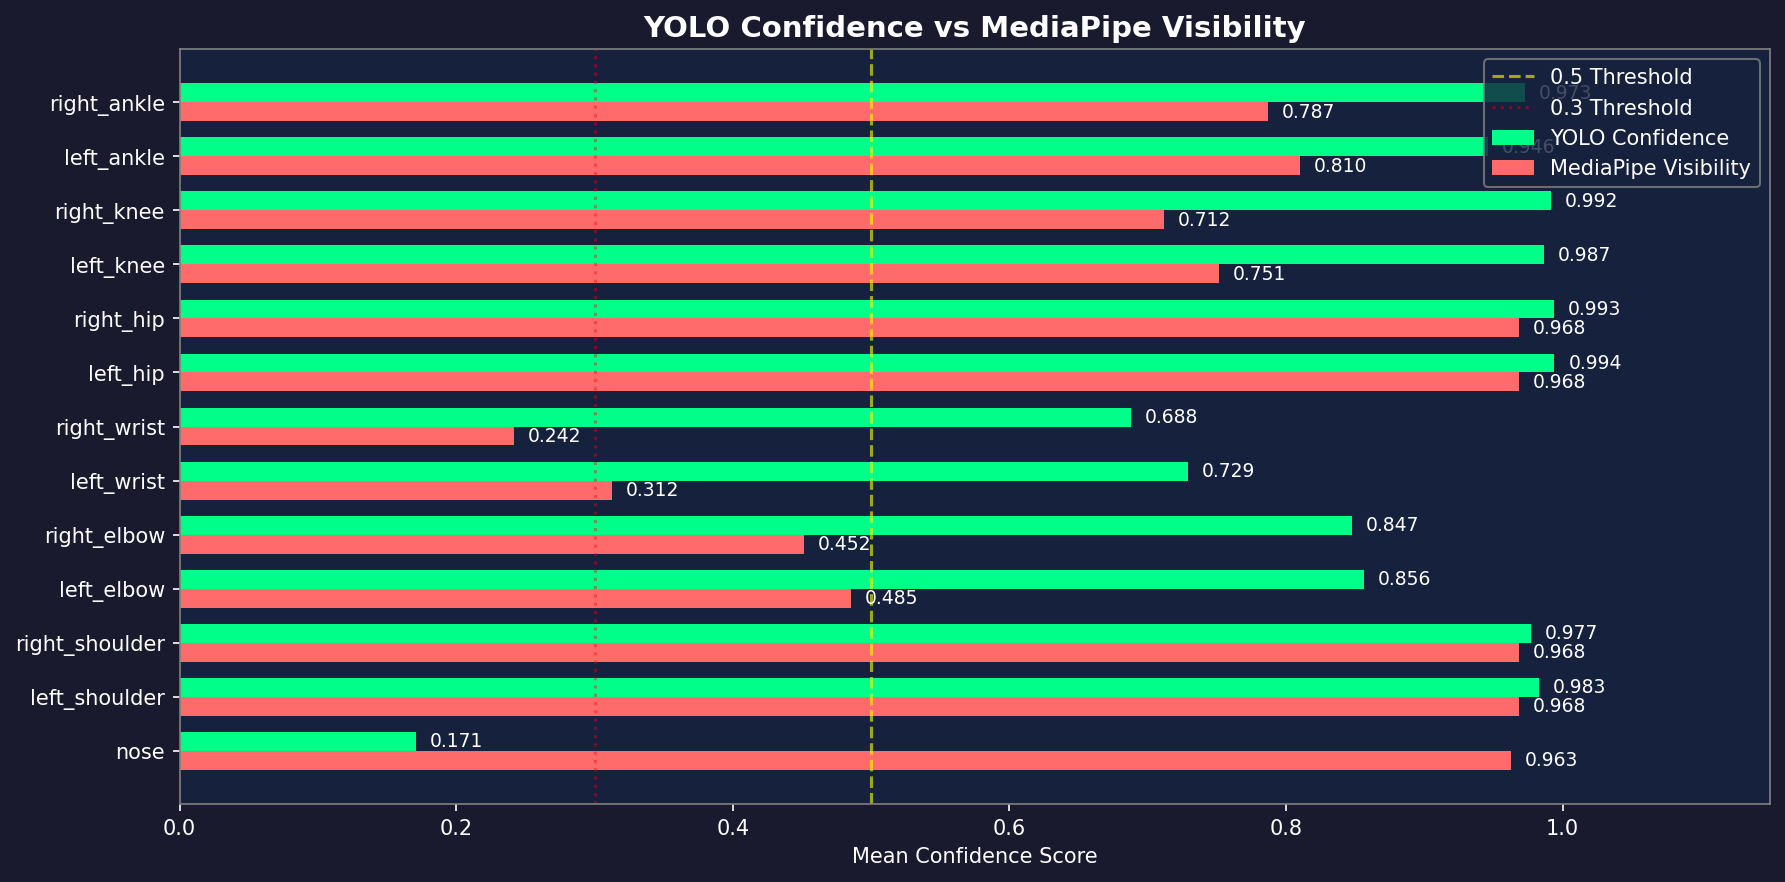

In [15]:
# ============================================================
# Cell 15: Plot 1 — Confidence bar plot per joint
# ============================================================

from IPython.display import Image as IPImage

print("\nPlotting Confidence Score Comparison Bar Plot...")
print(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

DARK_BG = "#1a1a2e"
PANEL_BG = "#16213e"
YOLO_COLOR = "#00ff88"    # green (YOLO)
MP_COLOR = "#ff6b6b"      # red (MediaPipe)

fig, ax = plt.subplots(figsize=(12, 6),facecolor=DARK_BG)
y_positions = np.arange(len(COMPARE_JOINTS))
bar_height = 0.35

yolo_means = [np.mean(yolo_confidence[n][:n_frames]) for n in COMPARE_JOINTS]
mp_means = [np.mean(mp_confidence[n][:n_frames]) for n in COMPARE_JOINTS]

bars1 = ax.barh(y_positions + bar_height/2, yolo_means, height=bar_height, color=YOLO_COLOR, label='YOLO Confidence')
bars2 = ax.barh(y_positions - bar_height/2, mp_means, height=bar_height, color=MP_COLOR, label='MediaPipe Visibility')

for bar, val in zip(bars1, yolo_means):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f"{val:.3f}", va='center', ha='left', color='white', fontsize=9)
for bar, val in zip(bars2, mp_means):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f"{val:.3f}", va='center', ha='left', color='white', fontsize=9)
    
ax.axvline(x=0.5, color='yellow', linestyle='--', alpha=0.6, label='0.5 Threshold')
ax.axvline(x=0.3, color='red', linestyle=':', alpha=0.4, label='0.3 Threshold')

ax.set_yticks(y_positions)
ax.set_yticklabels(COMPARE_JOINTS, color='white')
ax.set_xlabel('Mean Confidence Score', color='white')
ax.set_title('YOLO Confidence vs MediaPipe Visibility', fontsize=14, color='white', fontweight='bold')
ax.legend(fontsize=10, facecolor=PANEL_BG, edgecolor='gray', labelcolor='white')
ax.set_xlim(0, 1.15)
ax.set_facecolor(PANEL_BG)
ax.tick_params(colors='white')
for s in ax.spines.values():
    s.set_color('gray')
plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, "confidence_comparison_bar_plot.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.close()
print(f"Confidence comparison bar plot saved: {plot_path}")
display(IPImage(plot_path))


✅ Confidence timeline plot saved: C:\Rugby Coaching\output_YoloPose_Tackling_26\confidence_timeline.png


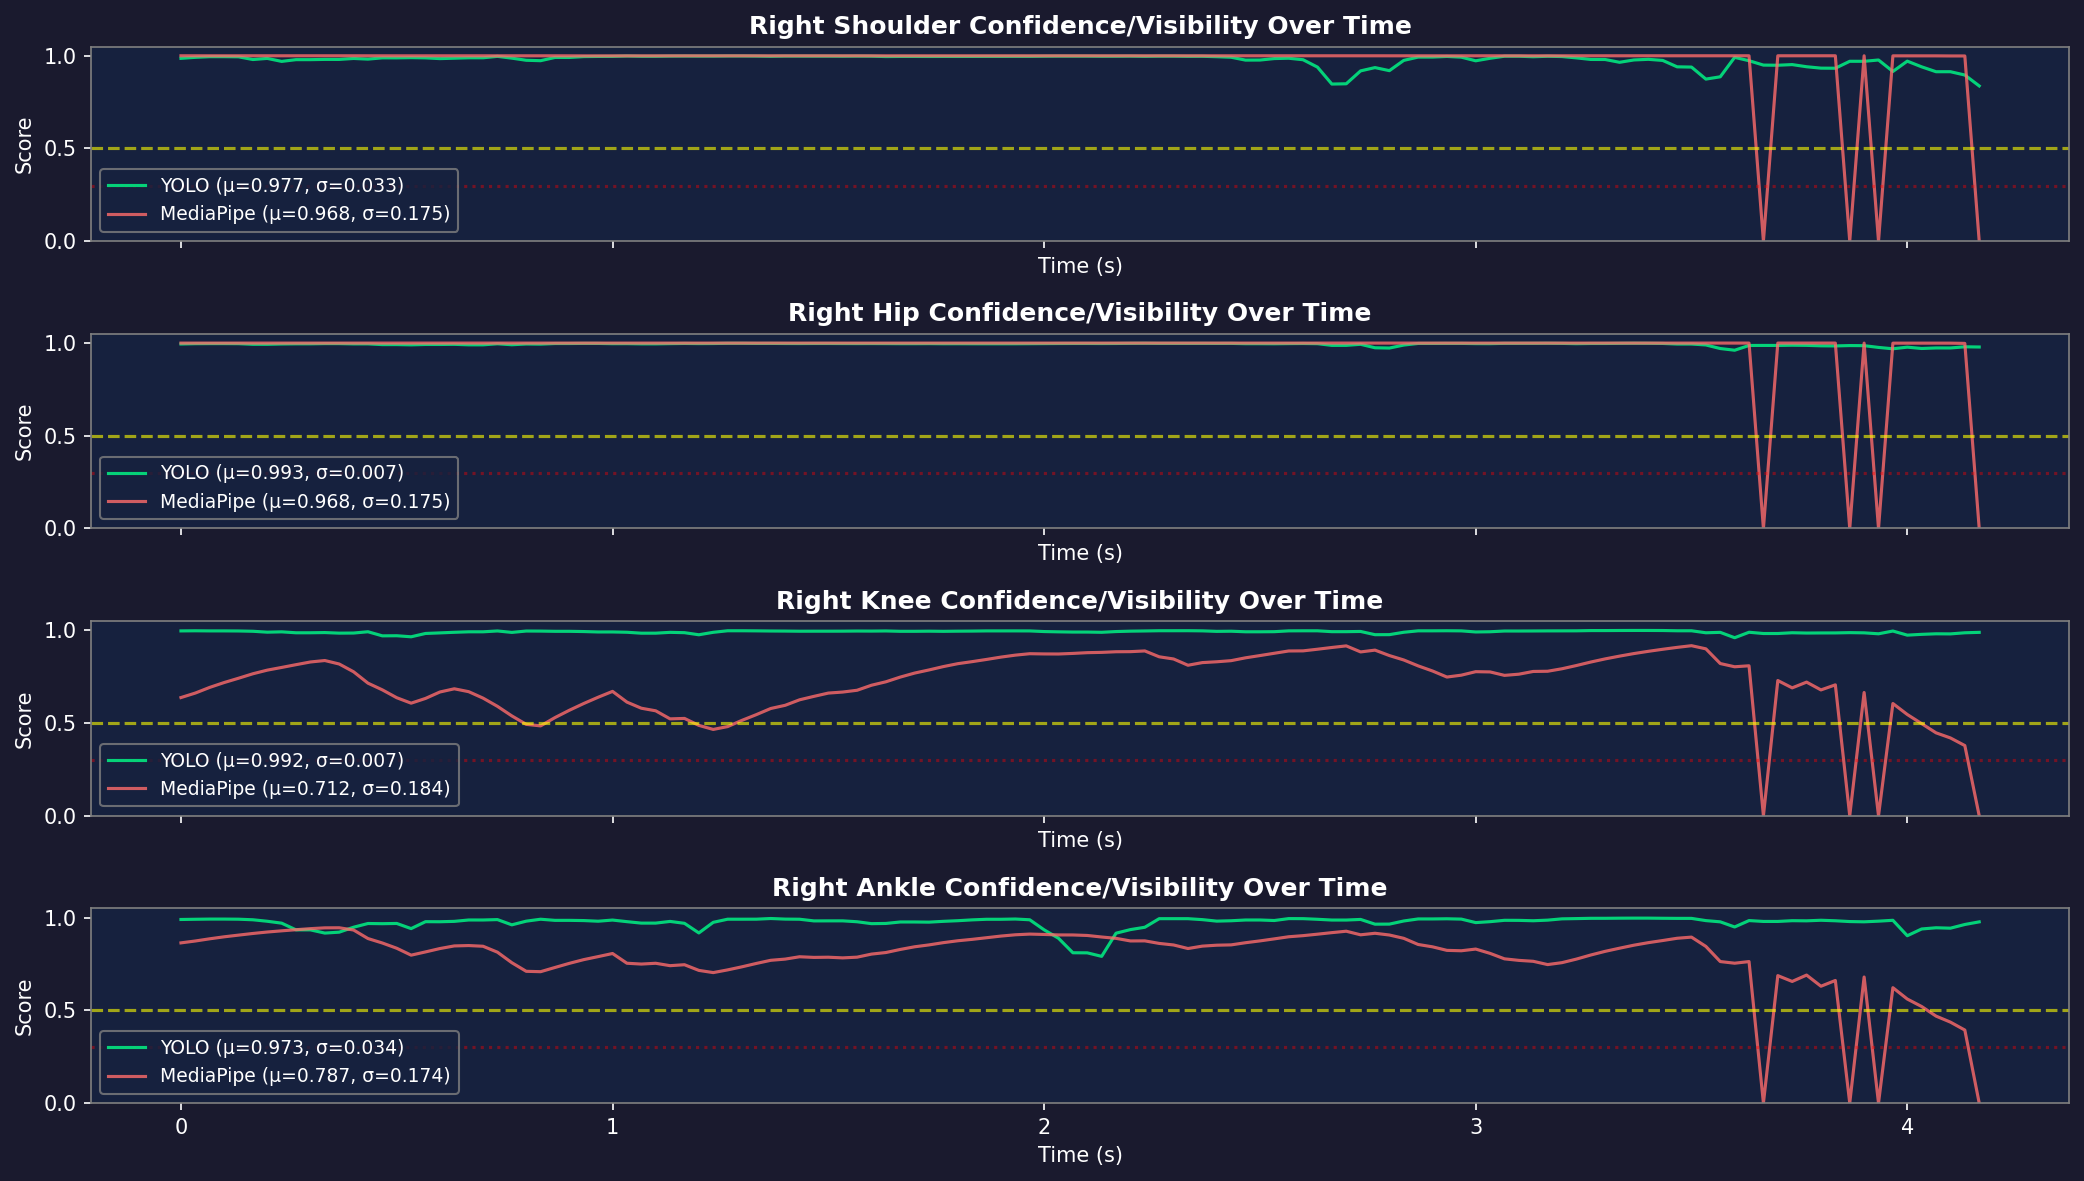

In [16]:
# ============================================================
# Timeline Confidence（Rep. 4 joints）
# ============================================================
#
KEY_JOINTS = ["right_shoulder", "right_hip", "right_knee", "right_ankle"]

fig, axes = plt.subplots(len(KEY_JOINTS), 1, figsize=(14, 8), sharex=True, facecolor=DARK_BG)
axes = axes.flatten()

time_axis = np.array(yolo_timestamps[:n_frames])

for idx, joint in enumerate(KEY_JOINTS):
    ax = axes[idx]
    
    y_vals = np.array(yolo_confidence[joint][:n_frames])
    m_vals = np.array(mp_confidence[joint][:n_frames])
    
    ax.plot(time_axis, y_vals, color=YOLO_COLOR, label=f'YOLO (μ={np.mean(y_vals):.3f}, σ={np.std(y_vals):.3f})', linewidth=1.5, alpha=0.8)
    ax.plot(time_axis, m_vals, color=MP_COLOR, label=f'MediaPipe (μ={np.mean(m_vals):.3f}, σ={np.std(m_vals):.3f})', linewidth=1.5, alpha=0.8)
    
    ax.axhline(0.5, color='yellow', linestyle='--', alpha=0.6)
    ax.axhline(0.3, color='red', linestyle=':', alpha=0.4)
    
    ax.set_title(f"{joint.replace('_', ' ').title()} Confidence/Visibility Over Time", fontsize=12, color='white', fontweight='bold')
    ax.set_ylabel("Score", color='white')
    ax.set_xlabel("Time (s)", color='white')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9, facecolor=PANEL_BG, edgecolor='gray', labelcolor='white')
    ax.set_facecolor(PANEL_BG)  
    ax.tick_params(colors='white')
    for s in ax.spines.values():
        s.set_color('gray')
plt.tight_layout()
timeline_path = os.path.join(OUTPUT_DIR, "confidence_timeline.png") 
plt.savefig(timeline_path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.close()
print(f"✅ Confidence timeline plot saved: {timeline_path}")
display(IPImage(timeline_path))

Confidence heatmaps saved: C:\Rugby Coaching\output_YoloPose_Tackling_26\confidence_heatmaps.png


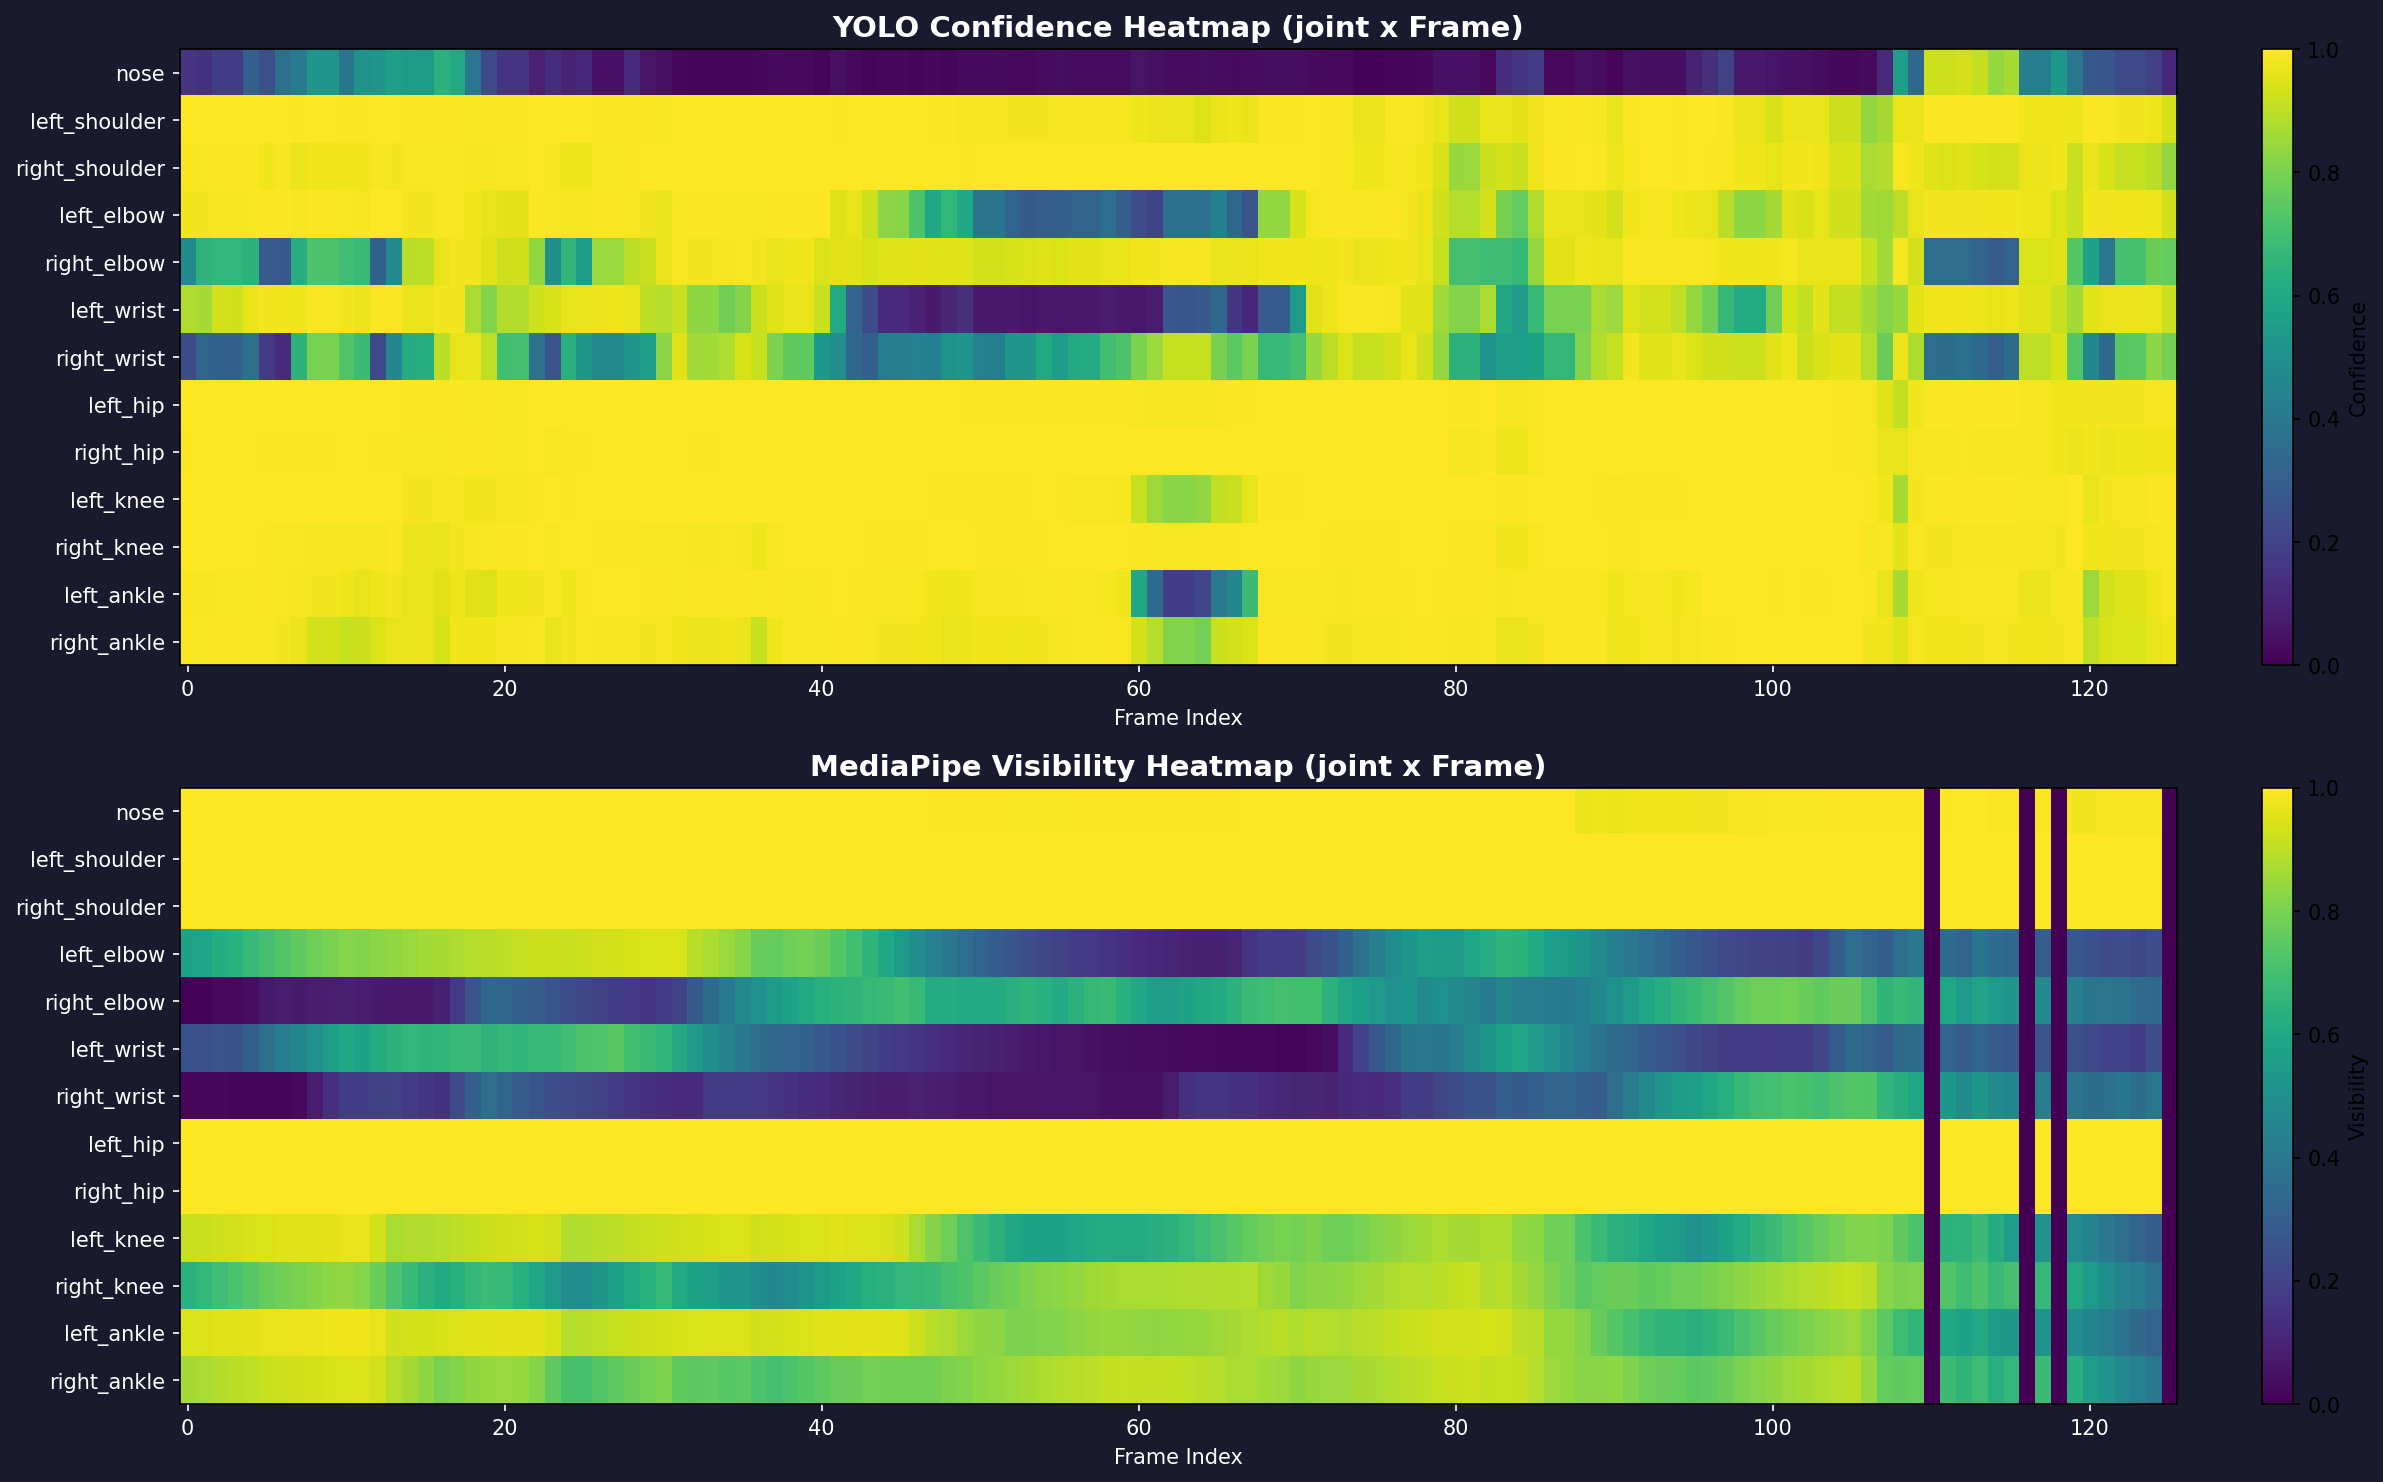

In [17]:
# ============================================================
# HeatMap (Frame x Joint Confidence Map)
# ============================================================
#
# What is a heatmap?
#
#   A visualization technique that represents values in a matrix M[i, j]
#   as color shading.
#   
#   Matrix structure used here:
#   +----------------------------------------------+
#   | Frame 0  Frame 1  Frame 2  ...  Frame N       | (horizontal axis)
#   | +---------------------------------------+     |
#   | | ████ ████ ████ ... ████             |     | Joint 0 (Nose)
#   | | ████ ██░░ ████ ... ░░░░             |     | Joint 1 (L_Shoulder)
#   | | ████ ████ ████ ... ████             |     | Joint 2 (R_Shoulder)
#   | |  ░░   ██   ░░  ...  ░░              |     | Joint 3 (L_Elbow)
#   | | ░░░░ ░░░░ ░░░░ ... ░░░░             |     | Joint 4 (R_Elbow)
#   | | ...                                  |     |  ...
#   | +---------------------------------------+     |
#   | (vertical axis: each joint)                   |
#   |                                               |
#   | Legend: ████ = high confidence (0.8~1.0)      |
#   |         ██░░ = medium confidence (0.4~0.6)    |
#   |         ░░░░ = low confidence (0.0~0.2)       |
#   +----------------------------------------------+
#
# Meaning of rows and columns:
#
#   Rows (Y-axis):  Each joint in COMPARE_JOINTS (13 joints)
#                   - Represents the spatial position information of each joint
#                   - nose, shoulders, elbows, wrists, hips, knees, ankles
#
#   Columns (X-axis): Frame number (0 to N_FRAMES)
#                     - Represents time progression through the video
#                     - Time advances left to right
#                     - Evenly spaced (every frame)
#
#   Value M[i, j]: confidence_score or visibility
#                  - Range: 0 to 1.0
#                  - Close to 1.0 = that joint was "reliably detected" in that frame
#                  - Close to 0.0 = "not detected" or "not visible"
#
# Color meaning (viridis colormap)
#
#   Viridis is a perceptually uniform colormap (equal perceptual color change):
#   
#       purple -> blue -> cyan -> green -> yellow -> white
#         0.0      0.2    0.4     0.6      0.8       1.0
#
#   Properties:
#     - Distinguishable by people with color blindness (uniform in CIE Lab space)
#     - Distinguishable even when converted to grayscale
#     - 0 and 1 are intuitively recognizable (dark = low, bright = high)
#
#   Interpretation of this figure:
#     Purple/dark areas  <- low confidence (0~0.3)
#     Green areas        <- medium confidence (0.4~0.6)
#     Yellow areas       <- high confidence (0.7~0.9)
#     White areas        <- very high confidence (0.95~1.0)
#
# Statistical meaning (spatio-temporal patterns of confidence scores)
#
#   "Bands" or "patterns" shown by the heatmap:
#
#   1. "Vertical dark bands (a column is consistently dark)"
#      -> "Multiple joints became invisible at the same moment"
#      -> Causes: occlusion (another person or ball in the way), motion blur
#      -> Rugby analysis interpretation:
#         - The moment of a tackle where both players overlap -> hard to detect
#         - The moment the ball carrier falls -> posture collapses
#
#   2. "Horizontal dark bands (a row is consistently dark)"
#      -> "That joint was hard to see for most of the video"
#      -> Causes: model weakness, ambiguity in keypoint definition
#      -> Example: finger joints are hard to detect in YOLO (YOLO has no finger keypoints)
#
#   3. "Diagonal / scattered dark spots"
#      -> "That joint becomes invisible irregularly"
#      -> Causes: dynamic movement, camera viewpoint changes
#
#   4. "Bright overall"
#      -> "Both models are robust and detection is stable"
#      -> Recommendation: this frame range is reliable for angle calculation
#
# Example uses in rugby analysis:
#
#   Question 1: "Which joint becomes invisible at which moment?"
#   Answer: Find dark spots in the heatmap and check the corresponding time
#   
#   Question 2: "Does detection degrade at the moment of a tackle?"
#   Answer: Look at the heatmap for the tackle interval (specified by time in advance)
#           and count the density of dark columns
#   
#   Question 3: "Which model is more robust, YOLO or MediaPipe?"
#   Answer: Compare the two heatmaps side by side -> compare the amount of dark area
#
# Mathematical definition
#
#   Heatmap M in R^(13 x N):
#   
#     M[i, t] = confidence_score(joint_i, frame_t)
#     
#   where:
#     i in {0, 1, ..., 12} (joint index)
#     t in {0, 1, ..., N_FRAMES-1} (frame index)
#     confidence_score in [0, 1] (detector output)
#
#   Color mapping at visualization time:
#     color(M[i, t]) = viridis_colormap( M[i, t] )
#
#   Note: viridis_colormap maps 0 -> purple, 1 -> yellow
#
# Expected "dark regions" in rugby:
#
#   Tackle scene:
#     - Attacker and defender make contact -> parts of both are hidden
#     - Especially lower body (legs) and torso make contact
#     -> Lower body joint confidence (ankles, knees, hips) drops
#       -> Result: columns appear in the heatmap where lower-body rows temporarily darken

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(16, 10), facecolor=DARK_BG)

# YOLO heatmap
yolo_matrix = np.array([yolo_confidence[n][:n_frames] for n in COMPARE_JOINTS])
im1 = ax1.imshow(yolo_matrix, aspect='auto', cmap='viridis', vmin=0, vmax=1)
ax1.set_yticks(range(len(COMPARE_JOINTS)))
ax1.set_yticklabels(COMPARE_JOINTS, color='white')
ax1.set_xlabel("Frame Index", color='white')
ax1.tick_params(colors='white')
ax1.set_title("YOLO Confidence Heatmap (joint x Frame)", fontsize=14, color='white', fontweight='bold')
plt.colorbar(im1, ax=ax1, label='Confidence',fraction=0.02, pad=0.04)

# MediaPipe heatmap
mp_matrix = np.array([mp_confidence[n][:n_frames] for n in COMPARE_JOINTS])
im2 = ax2.imshow(mp_matrix, aspect='auto', cmap='viridis', vmin=0, vmax=1)
ax2.set_yticks(range(len(COMPARE_JOINTS)))
ax2.set_yticklabels(COMPARE_JOINTS, color='white')
ax2.set_xlabel("Frame Index", color='white')
ax2.tick_params(colors='white')
ax2.set_title("MediaPipe Visibility Heatmap (joint x Frame)", fontsize=14, color='white', fontweight='bold')
plt.colorbar(im2, ax=ax2, label='Visibility',fraction=0.02, pad=0.04)

for ax in [ax1, ax2]:
    ax.set_facecolor(PANEL_BG)

plt.tight_layout()
heatmap_path = os.path.join(OUTPUT_DIR, "confidence_heatmaps.png")
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.close()
print(f"Confidence heatmaps saved: {heatmap_path}")
display(IPImage(heatmap_path))


Correlation scatter plots saved: C:\Rugby Coaching\output_YoloPose_Tackling_26\confidence_correlation_scatter.png


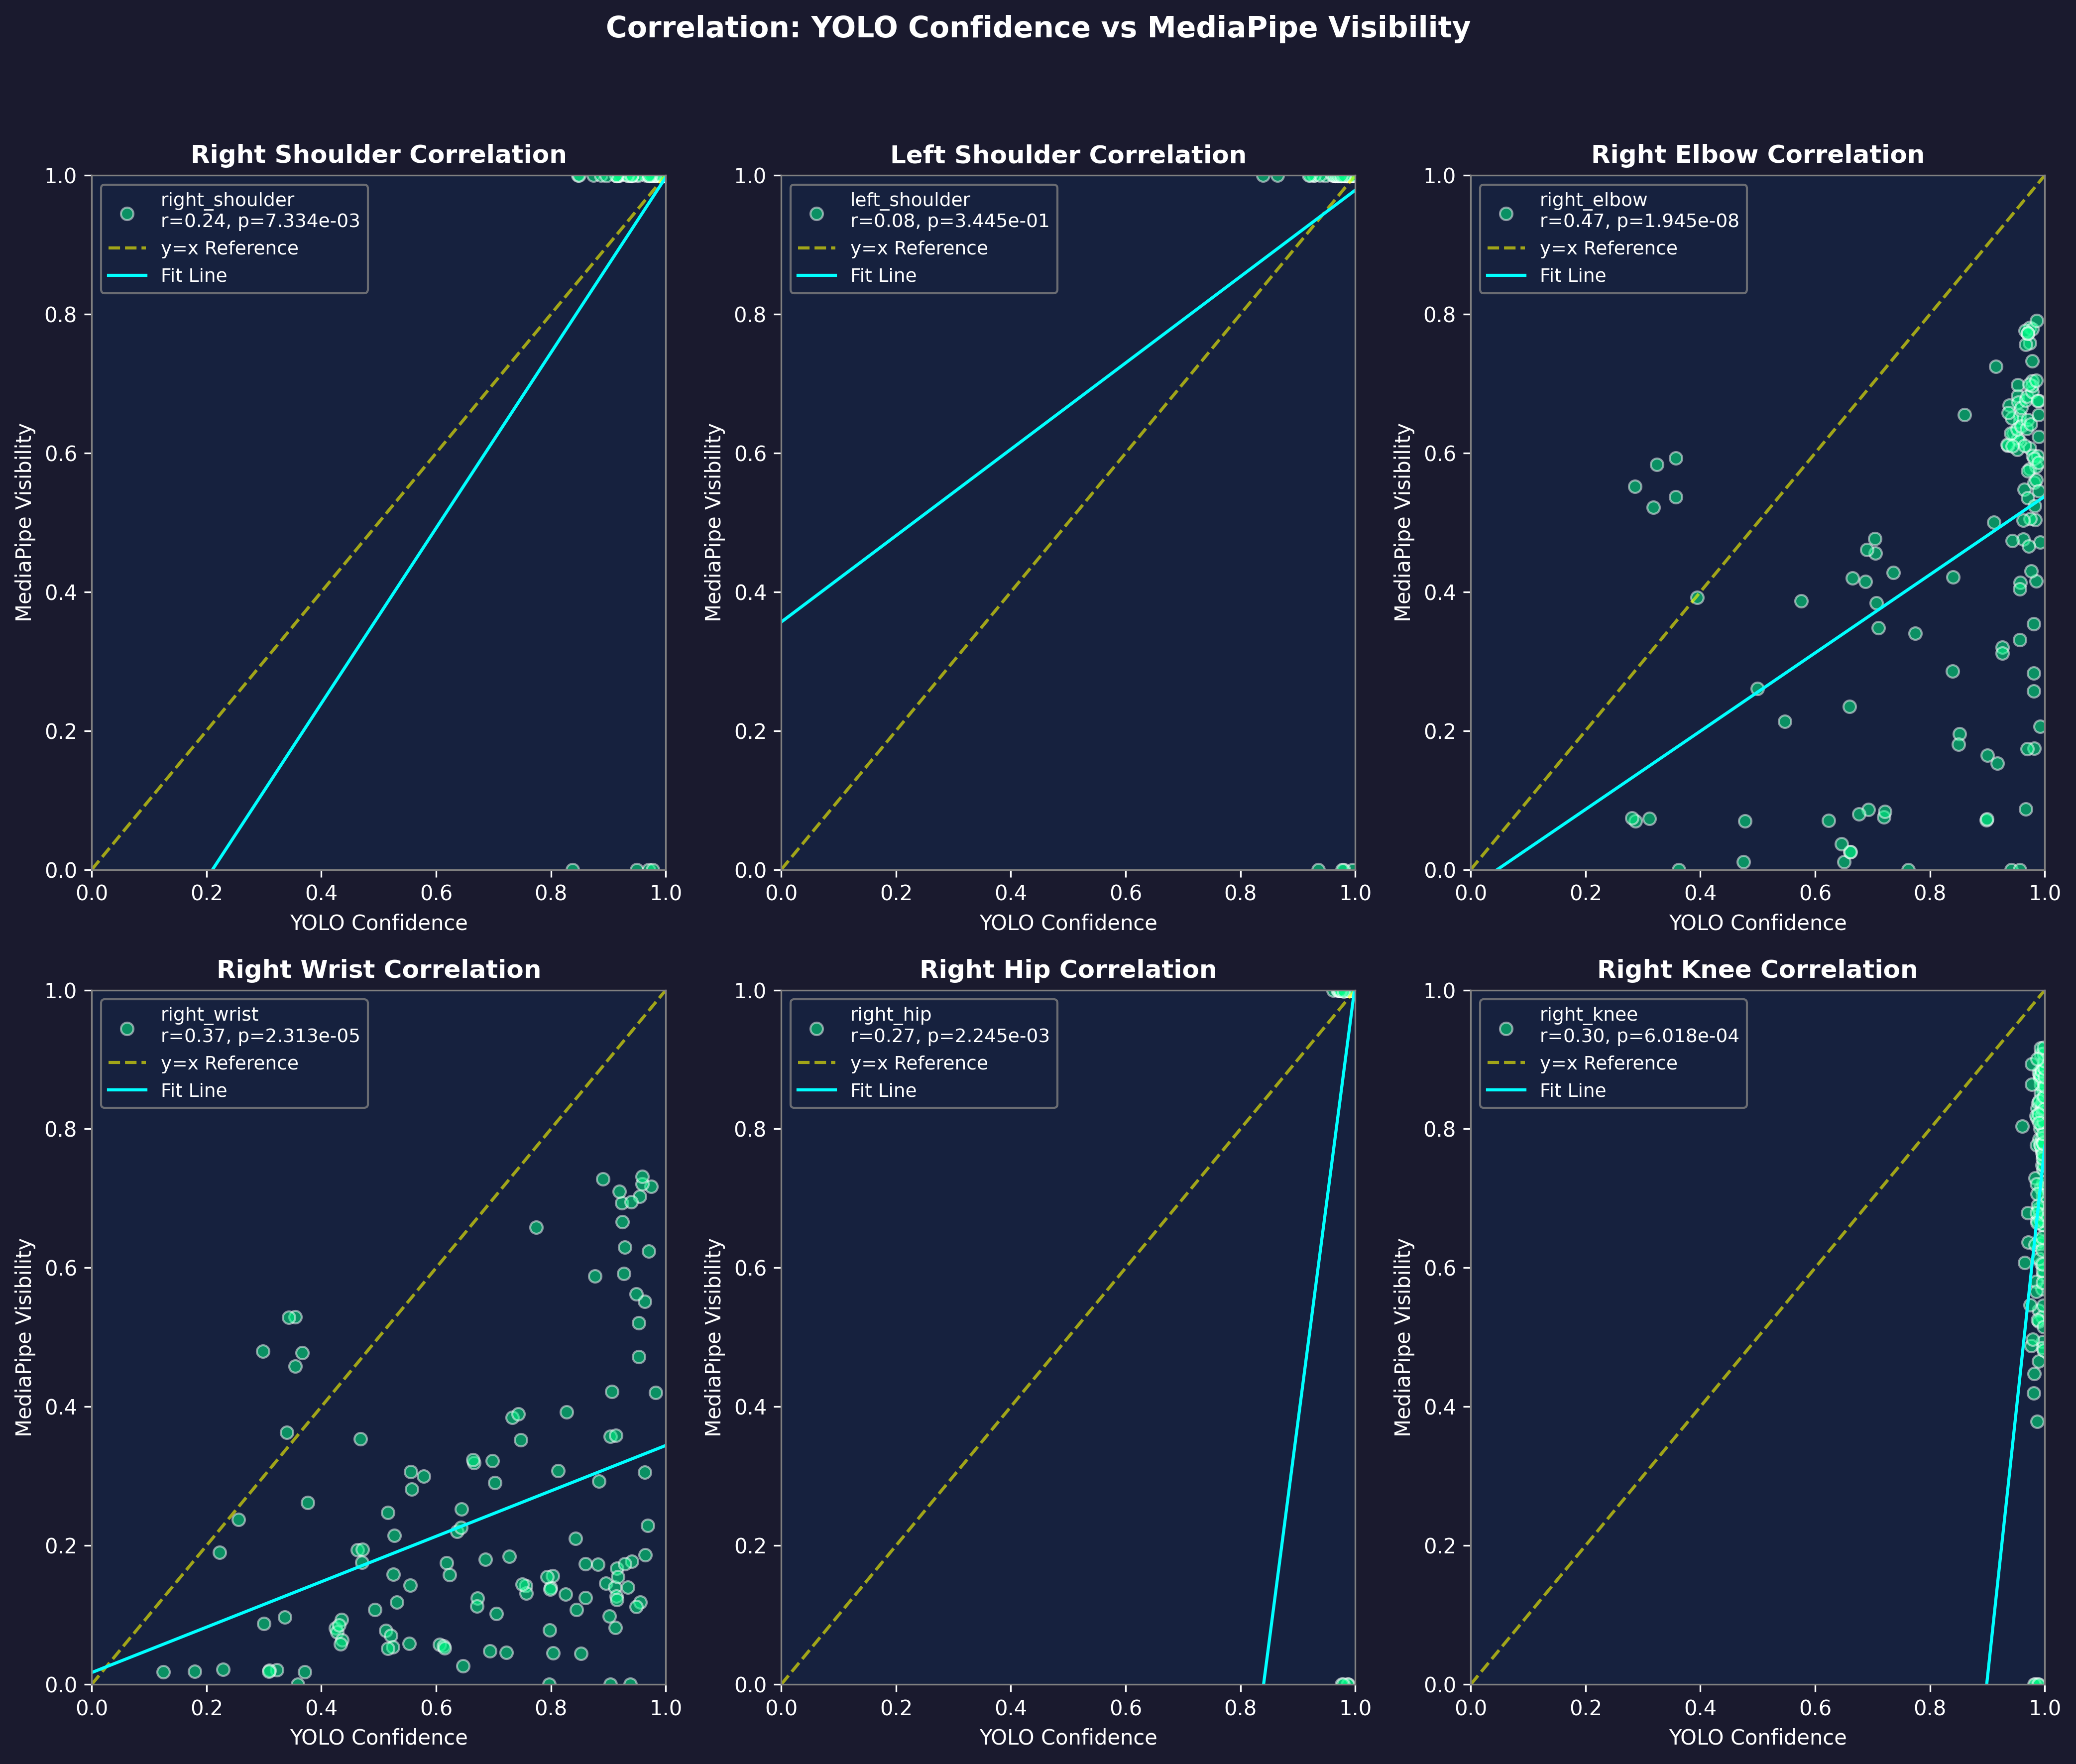

In [18]:
# ============================================================
# Cell 19: Plot 5 — Correlation Scatter Plot (YOLO Confidence vs MediaPipe Visibility)
# ============================================================
#
# Mathematical background:
#   Look at the correlation between YOLO confidence and MediaPipe visibility
#   for the same frame and the same joint.
#   
#   Pearson correlation coefficient r:
#     r = sum((x_i - x_mean)(y_i - y_mean)) / sqrt[sum((x_i - x_mean)^2 * sum((y_i - y_mean)^2)]
#   
#   r ~  1 : Both models make the same judgment for the same frame
#   r ~  0 : No relationship between the two models' judgments (different targets)
#   r <  0 : Opposite judgments (rare but important)
#
#   Rugby interpretation:
#   High correlation = "difficult frames" are shared = caused by occlusion
#   Low correlation  = models have different weaknesses = potentially complementary

from scipy import stats

fig, axes = plt.subplots(2, 3, figsize=(14, 12), facecolor=DARK_BG)
axes = axes.flatten()

# Scatter plot for six joints
SCATTER_JOINTS = ["right_shoulder", "left_shoulder", "right_elbow",
                  "right_wrist", "right_hip", "right_knee"]

for idx, joint in enumerate(SCATTER_JOINTS):
    ax = axes[idx]
    y_vals = np.array(yolo_confidence[joint][:n_frames])
    m_vals = np.array(mp_confidence[joint][:n_frames])
    
    r, p = stats.pearsonr(y_vals, m_vals)
    
    ax.scatter(y_vals, m_vals, alpha=0.5, color=YOLO_COLOR, edgecolor='white', label=f'{joint}\nr={r:.2f}, p={p:.3e}')
    ax.plot([0, 1], [0, 1], color='yellow', linestyle='--', alpha=0.6, label='y=x Reference')
    
    if len(y_vals) > 2:
        slope,intercept = np.polyfit(y_vals, m_vals, 1)
        x_fit = np.linspace(0, 1, 100)
        ax.plot(x_fit, slope*x_fit + intercept, color='cyan', 
                linewidth=1.5, label='Fit Line')
    

    ax.set_xlabel('YOLO Confidence', color='white')
    ax.set_ylabel('MediaPipe Visibility', color='white')
    ax.set_title(f'{joint.replace("_", " ").title()} Correlation', fontsize=12, color='white', fontweight='bold')
    ax.legend(fontsize=9, facecolor=PANEL_BG, edgecolor='gray', labelcolor='white')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_facecolor(PANEL_BG)
    ax.tick_params(colors='white')
    for s in ax.spines.values():
        s.set_color('gray')
fig.suptitle(
    "Correlation: YOLO Confidence vs MediaPipe Visibility",
    fontsize=14,
    color='white',
    fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
correlation_path = os.path.join(OUTPUT_DIR, "confidence_correlation_scatter.png")
plt.savefig(correlation_path, dpi=300, bbox_inches='tight')
plt.close()
print(f"Correlation scatter plots saved: {correlation_path}")
display(IPImage(correlation_path))
